# Sharpe-optimised fee drag search with partial-day rebalance cadences

Based on `63-opt-fee-drag-mitigation-10bps.ipynb`. Three changes:

1. **Optimise for Sharpe instead of Calmar.**
2. **Partial-day cadences.** The engine steps every **2 hours** (`cycle_duration = CycleDuration.cycle_2h`),
   the coarsest clock on which 40h and 54h are expressible alongside 24h, 36h, 48h, 60h and 72h.
   Candles and indicators stay daily; only the decision clock is finer.
3. **More iterations** - 34 rather than 18, giving 204 evaluations over a 112-cell space.

The 10 BPS vault exit fee, the 35% concentration ceiling and the 6-vault basket are unchanged from
NB63, as is the hl-min-1000 dataset and the 2026-01-01 to 2026-07-10 window.

## This notebook needs two trade-executor fixes

Both were found by running this notebook and both are in `fix/optimiser-cycle-duration`.

1. **`perform_optimisation()` dropped `cycle_duration`.** It never forwarded the parameter to
   `run_grid_search_backtest()`, which fell back to
   `CycleDuration.from_timebucket(candles.time_bucket)` - daily. The first run of this notebook was
   therefore executed on a daily clock and reproduced NB63 cell for cell with every cadence label
   wrong by a factor of twelve.
2. **The candle width cache aliased garbage collected indexes.**
   `_calculate_and_cache_candle_width()` keyed on `id(index)`, which is unique only among *live*
   objects; indicator lookups build short-lived series, so a collected index frees its address for
   the next one and the cache serves it the dead index's width. This notebook mixes an hourly `tvl`
   series with daily indicators, so a daily indicator could resolve at a 1h width. Off the daily
   grid that raises `IndicatorDataNotFoundWithinDataTolerance` - which is how it was found, when
   the 2h clock crashed a 36h backtest at 2026-02-07 12:00. **On** the daily grid it does not
   raise: the previous-bar lookup misses and the forward-fill fallback returns the value at the
   *current* timestamp, i.e. silent lookahead bias.

The second one is checked below and did **not** affect the earlier results.

## Key new insights and what did we learn from this experiment?

### 40h wins, and that is the reason not to believe the cadence axis

Best configuration at each cadence (`minimum_hold_days=1`, `$250` band):

| Cadence | CAGR | Max DD | Sharpe | Sortino | Calmar | Trades | Turnover | Trades off 00:00 |
|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| 24h | 18.36% | -7.65% | 1.032 | 1.396 | 2.399 | 580 | 16.1x | 0% |
| 36h | 17.87% | -6.46% | 0.977 | 1.359 | 2.767 | 441 | 12.5x | 41% |
| **40h** | **39.48%** | -6.62% | **1.956** | **2.891** | **5.959** | 425 | 13.1x | 63% |
| 48h | 34.03% | -6.63% | 1.705 | 2.497 | 5.130 | 402 | 12.5x | 0% |
| 54h | 32.99% | -6.68% | 1.617 | 2.344 | 4.942 | 379 | 11.5x | 70% |
| 60h | *crashed* | | | | | | | |
| 72h | 12.56% | -7.57% | 0.701 | 0.938 | 1.660 | 313 | 9.7x | 0% |

40h beats the previous winner by **5.5 pp of CAGR at the same drawdown**, and it does so at every
softband level (Sharpe 1.940 to 1.956 across all four), so it is not one lucky cell.

**It is still almost certainly noise.** The mean Sharpe by cadence at a non-binding hold reads

    24h 1.014   36h 0.963   40h 1.950   48h 1.694   54h 1.609   60h 0.190   72h 0.702

Neighbouring cadences run the *same* strategy over the *same* daily data and differ only in when
they look at it. A 4-hour change from 36h to 40h moves Sharpe by **+1.0**; a 6-hour change from 54h
to 60h moves it by **-1.4**. Effects of that magnitude cannot be structural - there is no mechanism
by which looking at an unchanged daily series eight hours earlier doubles the return.

The drawdown column is the tell: it sits between -6.4% and -6.7% for every cadence from 36h to 54h
while CAGR swings from 17.9% to 39.5%. The differences are coming from a handful of well- or
badly-timed entries and exits on individual positions, not from any systematic improvement in risk
control.

### The levers barely reduce the fee bill - this notebook measures timing, not drag

All three NB63 mitigation levers are searched here and the 10 BPS fee is applied and verified
(median implied fee 0.100% on the reported configurations). But decomposing the gain shows the
levers are not working the way the notebook's title claims:

| Configuration | CAGR | Trades | Turnover | Fee paid |
|---|---:|---:|---:|---:|
| 24h + $5 - no mitigation | 17.67% | 864 | 16.4x | $410 |
| 24h + $250 - softband only | 18.36% | 580 | 16.1x | $403 |
| 48h + $5 - cadence only | 33.45% | 514 | 12.6x | $315 |
| 48h + $250 - both | 34.03% | 402 | 12.5x | $313 |

Fully unmitigated to fully mitigated saves **$97** of fee on a $25,000 bankroll over 190 days,
about **0.74 pp of annualised return**. The CAGR gap between those same two rows is **16.4 pp**.
So roughly **5% of the improvement is fee saving** and 95% is the cadence changing which vaults are
held and when.

The softband makes the point sharpest. At 24h, moving from $5 to $250 removes 284 trades (-33%) but
only 2% of sell *volume* - it suppresses small trims while the fee is paid on the large ones - so it
saves **$7** of fee and adds **0.69 pp** of CAGR. Whatever that 0.69 pp is, it is not a cost saving.

The 10 BPS drag itself is real and matches NB62: ~$410 unmitigated is 1.6% of capital over the
window, ~3.2%/yr, against NB62's ~0.33 pp of CAGR per BPS. **The levers recover under a quarter of
it.** The rest of the measured spread is the timing effect that the cadence analysis above argues is
mostly noise.

### Which is why 48h, not 40h, is still the right answer

Read the surface as a landscape rather than a ranking:

- **40h is a cliff edge.** Its left neighbour, 36h, scores 0.963 - the second-worst cadence measured.
- **48h sits on a plateau.** Its neighbours are 40h (1.950) and 54h (1.609); everything within
  +/-8h of it is good.

A parameter you must hit within a few hours to get the advertised return is not a parameter you can
run. 48h is the choice that survives being slightly wrong, which is the property that matters when
the next 190 days do not look like these ones.

### The partial-day cadences do operate differently, so the rows are real

24h, 48h and 72h place **100%** of their trades at 00:00 - they are exact multiples of the candle
bucket, so they never see anything the daily clock would not. 36h, 40h and 54h place 41%, 63% and
70% of trades off the daily grid, rotating through the hours of the day (40h trades at 00:00, 08:00
and 16:00; 54h at 00:00, 06:00, 12:00 and 18:00). Whatever these rows are measuring, they are not
measuring the same schedule under a different name.

### At 40h the hold and softband structure breaks down

At 48h the levers were orderly: holds 1 and 2 identical, softband monotone. At 40h neither holds.

| Lever | At 48h | At 40h |
|---|---|---|
| `minimum_hold_days` | 1 = 2 (1.694), 3 = 4 (1.196) | 1 (1.950) >> 2 = 3 (1.353), 4 (1.376) |
| Softband $5 -> $250 | monotone, 1.687 -> 1.705 | flat and unordered, 1.950 / 1.954 / 1.940 / 1.956 |

The softband effect at 48h was small but strictly ordered across five levels, which is what a real
cost saving looks like. At 40h the same lever produces an unordered scatter of the same magnitude
as its own noise - further evidence that the 40h cell is riding path luck rather than economics.

## Summary of results

Best configuration found: **40h cadence (`rebalance_every_n_cycles=20`), `minimum_hold_days=1`,
`sell_rebalance_min_threshold_usd=250`** - CAGR 39.48%, Sharpe 1.956, Calmar 5.959, -6.62%
drawdown, 425 trades, 13.1x turnover (25.1x annualised).

**Recommended configuration: unchanged at 48h**, `minimum_hold_days=1`,
`sell_rebalance_min_threshold_usd=125-250`, for the robustness reasons above.

| Metric | 40h (best found) | 48h (recommended) | 24h (baseline) |
|---|---:|---:|---:|
| CAGR | **39.48%** | 34.03% | 18.36% |
| Max drawdown | **-6.62%** | -6.63% | -7.65% |
| Sharpe | **1.956** | 1.705 | 1.032 |
| Sortino | **2.891** | 2.497 | 1.396 |
| Calmar | **5.959** | 5.130 | 2.399 |
| Trades | 425 | **402** | 580 |
| Redemption turnover | 13.1x (25.1x/yr) | **12.5x (24.0x/yr)** | 16.1x (30.9x/yr) |
| Worst neighbouring cadence | 0.963 Sharpe (36h) | **1.609 Sharpe (54h)** | 0.963 Sharpe (36h) |

## Robustness of results

- **The candle width bug did not contaminate the earlier results.** Where the pre-fix 12h-clock run
  and this post-fix 2h-clock run share both a cadence and the same set of configurations, the
  metrics are identical to six decimal places:

  | Cadence | Configs | CAGR 12h run (pre-fix) | CAGR 2h run (post-fix) | Sharpe 12h | Sharpe 2h |
  |---:|---:|---:|---:|---:|---:|
  | 24h | 4 | 0.179354 | 0.179354 | 1.014370 | 1.014370 |
  | 36h | 4 | 0.175016 | 0.175016 | 0.962610 | 0.962610 |
  | 48h | 8 | 0.336743 | 0.336743 | 1.694124 | 1.694124 |

  Lookahead would have changed these. It did not, so NB63's daily-clock numbers and the 12h run
  stand. The aliasing crashed this notebook rather than quietly corrupting its predecessors.
- **Three clocks agree on the cadences they share.** NB63's daily clock, the 12h clock and this 2h
  clock give the same answer at 24h, 48h and 72h to within 0.03 pp of CAGR. The decision clock
  itself changes nothing; only which days the strategy acts on does.
- **Coverage: 204 evaluations reaching 102 of the 112 cells (91%), 98 scored.** 98 evaluations were
  repeats and are dropped before any marginal is computed, so the per-lever means are not weighted
  by what the Gaussian Process preferred. The GP spent its repeats on the 40h-54h ridge.
- **Four combinations crashed**, all at **60h with the $250 band** (holds 1-4,
  `BacktestExecutionFailed`). The 60h row therefore rests on the surviving narrow-band
  configurations, and its widest-band corner is unmeasured. 60h is also the worst-performing
  cadence, so its collapse and its crashes are the same region of the space.
- **Metrics are recomputed from each result's return series, resampled to daily first.**
  `GridSearchResult.returns` is sampled once per cycle - 2280 points over 190 days at this clock -
  and quantstats computes Sharpe as `sqrt(periods) x mean/std`, so annualising the raw series with
  `periods=365` would understate Sharpe and Sortino by a factor of `sqrt(12)`. The search objective
  still reads the **rounded** quantstats metrics, so the GP ranked on a coarser signal than this
  table shows.
- **The fee is verified on more than one configuration**: median implied fee exactly 0.100% against
  a configured 0.100% on both the 40h winner and the best 24h configuration. Only ~51% of
  individual sells land within 1 BPS because Hypercore partial reductions execute at the position's
  marked price rather than the current close; NB62 established this dispersion is present
  identically in a 0 BPS control.
- **The grid search cache key covers only the searched parameters**, not the fee, the pinned
  concentration, the cycle duration or `decide_trades`. This notebook's cache had to be cleared by
  hand twice - once after the clock fix and once after the width fix. Clear
  `~/.cache/tradingstrategy/grid-search/64-opt-sharpe-partial-day-cadence-10bps/` after changing
  anything unsearched.
- **One in-sample window of 190 days in a single regime, and the central claim of this notebook is
  precisely that this is not enough.** Nothing here has been tested at 0 BPS or on a second window.

## What to do about it

1. **Keep the release candidate at 48h.** Do not move to 40h on this evidence, despite it being the
   best cell measured: it is the peak of a spike whose neighbour is near the bottom of the range.
2. **Treat cadence as settled and stop searching it.** Seven values at 6h resolution have produced
   a surface that swings a full Sharpe point between adjacent cells. Further refinement will find
   larger numbers and will not find a better strategy.
3. **Run the cadence axis on a second window before trusting any of it** - including the 48h
   result. If the 40h/48h/54h ordering reshuffles out of sample, the whole axis is timing luck and
   the RC should use whichever cadence is cheapest to operate.
4. **Widen the sell-side softband** to $125-250, as NB63 recommended - but for trade-count
   hygiene, not for fee savings. It removes a third of the trades while saving single-digit
   dollars of fee.
7. **Do not expect these levers to solve the fee problem.** They recover under a quarter of the
   ~3.2%/yr drag. If 10 BPS exits are the real constraint, the answer is fewer full exits or a
   lower-turnover selection rule, not a wider band.
5. **Leave `minimum_hold_days` at 1.** It never helps at any cadence measured.
6. **Do not run 60h with a wide band** - the only region in the sweep that crashes.


## Notebook setup

- Shared imports, chart output settings, and notebook logging for the clean-up variant.

In [1]:
import datetime
import logging

import pandas as pd
import plotly.express as px
from IPython.display import display

from tradingstrategy.client import Client
from tradeexecutor.utils.notebook import setup_charting_and_output, OutputMode

client = Client.create_jupyter_client()
setup_charting_and_output(OutputMode.static, image_format='png', width=1500, height=1000)
logger = logging.getLogger('strategy')

Started Trading Strategy in Jupyter notebook environment, configuration is stored in /Users/moo/.tradingstrategy


## Universe definition

- Use the same Hyperliquid survivor-first vault universe as NB152 so the clean-up stays directly comparable.

In [2]:
from eth_defi.token import USDC_NATIVE_TOKEN
from tradingstrategy.chain import ChainId
from tradeexecutor.state.identifier import AssetIdentifier

CHAIN_ID = ChainId.hyperliquid

EXCHANGES = ('uniswap-v2', 'uniswap-v3')
SUPPORTING_PAIRS = [
    (ChainId.arbitrum, 'uniswap-v3', 'WETH', 'USDC', 0.0005),
    (ChainId.ethereum, 'uniswap-v3', 'WETH', 'USDC', 0.0005),
    (ChainId.ethereum, 'uniswap-v3', 'WBTC', 'USDC', 0.003),
]
LENDING_RESERVES = None
PREFERRED_STABLECOIN = AssetIdentifier(
    chain_id=ChainId.hyperliquid.value,
    address=USDC_NATIVE_TOKEN[ChainId.hyperliquid].lower(),
    token_symbol='USDC',
    decimals=6,
)
ALLOWED_VAULT_DENOMINATION_TOKENS = {'USDC', 'USDT', 'USDC.e', 'crvUSD', 'USDT0', 'USD₮0', 'USDt', 'USDS'}

print(f'Chain universe: {CHAIN_ID.get_name()}')
print(f'Reserve asset: {PREFERRED_STABLECOIN}')


Chain universe: HyperEVM
Reserve asset: <USDC at 0xb88339cb7199b77e23db6e890353e22632ba630f>


## Parameters

- **Pinned**: `max_concentration_pct = 0.35`, `max_assets_in_portfolio = 6`, 10 BPS exit fee.
- The engine steps every 12 hours, so `rebalance_every_n_cycles` counts **12-hour cycles**:
  1 = 12h, 2 = 24h, 3 = 36h, 4 = 48h, 5 = 60h, 6 = 72h.
- **Searched**: `rebalance_every_n_cycles` (1-6), `minimum_hold_days` (1-4) and
  `sell_rebalance_min_threshold_usd` (5 / 50 / 125 / 250 USD).
- Hold values above 4 days and the 25 USD softband were dropped: NB63 measured both as
  monotonically worse or indistinguishable, and the space is better spent on cadence resolution.


In [3]:
from tradeexecutor.strategy.cycle import CycleDuration
from tradeexecutor.strategy.default_routing_options import TradeRouting
from tradeexecutor.strategy.parameters import StrategyParameters
from skopt.space import Categorical

from tradingstrategy.timebucket import TimeBucket


class Parameters:
    #: Notebook identifier.
    id = '64-opt-sharpe-partial-day-cadence-10bps'

    #: Daily candles match the whole Hyperliquid survivor-first research chain.
    candle_time_bucket = TimeBucket.d1
    #: The engine steps every 2 hours, the coarsest clock that expresses 40h and 54h alongside
    #: 24h, 36h, 48h, 60h and 72h. Candles and indicators stay daily; only the decision clock is
    #: finer. The traded cadence is imposed inside :py:func:`decide_trades` via
    #: :py:attr:`rebalance_every_n_cycles`.
    #:
    #: Requires the trade-executor fix that makes `perform_optimisation()` forward
    #: `cycle_duration` to `run_grid_search_backtest()`. Without it the optimiser silently falls
    #: back to `CycleDuration.from_timebucket(candles.time_bucket)`, i.e. a daily clock, and every
    #: cadence label below is wrong by a factor of twelve.
    cycle_duration = CycleDuration.cycle_2h
    #: HyperEVM is the primary chain for vaults.
    chain_id = CHAIN_ID
    #: HyperEVM is the primary execution chain.
    primary_chain_id = CHAIN_ID
    #: Same exchange set as the release-candidate notebooks.
    exchanges = EXCHANGES

    #: Pinned for this variant: the NB35/NB36 six-vault basket. Breadth is not a fee lever,
    #: and holding it fixed keeps the search on the three turnover parameters.
    max_assets_in_portfolio = 6
    #: 98% target deployment, the validated release default.
    allocation_pct = 0.98
    #: Pinned for this variant at the NB53 ceiling, as instructed.
    max_concentration_pct = 0.35
    #: Fixed for this variant: the NB36/NB53 release-candidate per-vault TVL cap.
    per_position_cap_of_pool_pct = 0.15
    #: Engine hygiene threshold for cleaning up tiny residual positions.
    min_portfolio_weight_pct = 0.005

    #: Searched: act only on every Nth **2-hour** strategy cycle.
    #: 12 = 24h, 18 = 36h, 20 = 40h, 24 = 48h, 27 = 54h, 30 = 60h, 36 = 72h.
    #:
    #: NB63 found 48h the optimum on a daily clock and the 12h-clock run of this notebook found
    #: 48h again, with 36h and 60h both worse - a one-cell-wide peak. 40h and 54h close the two
    #: remaining gaps around it, so the shape of the peak is measured at 6h resolution rather
    #: than inferred from its neighbours.
    #:
    #: The 12h control is dropped: the 12h-clock run showed every 12h configuration is
    #: byte-identical to the 24h configuration with the same hold and band, because a midday
    #: decision point has no new daily candle or indicator value to act on.
    rebalance_every_n_cycles = Categorical([12, 18, 20, 24, 27, 30, 36])
    #: Searched: keep an eligible incumbent's basket slot until the position is at least
    #: this many days old, even when composite ranking has pushed it out of the top
    #: :py:attr:`max_assets_in_portfolio`. Vaults dropped by the momentum gate or by the
    #: quarantine list are not protected, so this suppresses rank-drift churn only.
    #: ``1`` is effectively no hold at a daily cadence.
    minimum_hold_days = Categorical([1, 2, 3, 4])

    #: Hyperliquid has a hard 5 USD minimum deposit.
    absolute_min_vault_deposit_usd = 5.0
    #: Buy threshold as a fraction of initial cash. Deposits are free under an exit-only
    #: fee, so the buy side stays tight and is not searched.
    individual_rebalance_min_threshold_of_initial_cash_pct = 0.0005
    #: Searched: sell-side softband in USD. The release default floors at 5 USD, which is
    #: 0.02% of the bankroll, so nearly every weight drift triggers a trim; NB62 measured
    #: 543 such trims worth $263k. The ladder spans 0.02% to 1.0% of initial cash.
    #: Searched directly in USD because a fraction-of-cash parameter cannot be multiplied
    #: out at class creation time while it is a search dimension.
    sell_rebalance_min_threshold_usd = Categorical([5.0, 50.0, 125.0, 250.0])

    #: Survivor-first TVL floor selected in NB141.
    min_tvl_usd = 7_500

    #: Trailing window (days) for the CAGR leg of the composite selection score.
    cagr_lookback_days = 360
    #: Trailing window (days) for the Sharpe leg of the composite selection score.
    sharpe_lookback_days = 180
    #: Composite blend: ``cagr_weight x CAGR score + (1 - cagr_weight) x Sharpe score``.
    #: NB31 showed both legs are load-bearing: either leg alone is materially worse on
    #: both CAGR and drawdown.
    cagr_weight = 0.50
    #: Momentum gate window: a vault is eligible only while its trailing return over
    #: this window exceeds :py:attr:`gate_threshold`. NB31: pure drawdown insurance at
    #: zero return cost (removal: -4.5pp CAGR and max DD -7.4% -> -17.5%).
    gate_lookback_days = 14
    #: Momentum gate threshold (fraction).
    gate_threshold = -0.08
    #: Rolling window for the inverse-volatility sizing weight. NB31: the single
    #: biggest contributor - equal weight halves CAGR and triples drawdown.
    inverse_vol_window = 60

    #: Start trading from January 2026 while retaining pre-start indicator history.
    backtest_start = datetime.datetime(2026, 1, 1)
    #: Exclusive end boundary.
    backtest_end = datetime.datetime(2026, 7, 10)
    #: Release-candidate bankroll.
    initial_cash = 25_000
    #: Derived at class creation time from the configured initial cash and the 5 USD hard floor.
    individual_rebalance_min_threshold_usd = max(
        absolute_min_vault_deposit_usd,
        initial_cash * individual_rebalance_min_threshold_of_initial_cash_pct,
    )

    #: Optimiser runs do not model managed yield.
    use_managed_yield = False

    #: Default routing is still required by the strategy runtime even though it is not the alpha source.
    routing = TradeRouting.default
    #: Set deliberately high so live and notebook indicator calculations use effectively
    #: all available history; history-derived indicators would be silently biased by a
    #: truncated lookback window.
    required_history_period = datetime.timedelta(days=365 * 20)
    #: Same live-style slippage assumption as the release-candidate notebooks.
    slippage_tolerance_pct = 0.0060
    #: Vault exit fee charged on every Hypercore redemption. Applied to the trading
    #: universe as a sell-side token tax, see the universe cell.
    vault_redemption_fee = 0.0010
    #: Assume no liquidity if there is a gap in TVL data.
    assummed_liquidity_when_data_missings_usd = 0.01


parameters = StrategyParameters.from_class(Parameters)

from tradeexecutor.strategy.parameters import display_parameters

display_parameters(parameters)


,Value,Type
Name,,
absolute_min_vault_deposit_usd,5.0,float
allocation_pct,0.98,float
assummed_liquidity_when_data_missings_usd,0.01,float
backtest_end,2026-07-10 00:00:00,datetime
backtest_start,2026-01-01 00:00:00,datetime
cagr_lookback_days,360,int
cagr_weight,0.5,float
candle_time_bucket,TimeBucket.d1,TimeBucket
chain_id,999,ChainId


## Trading universe

- Build the tradable supporting-pair and Hyperliquid vault universe used by the backtest.

In [4]:
from pathlib import Path
import shutil
import time

from dotenv import load_dotenv
from tradingstrategy.utils.token_filter import filter_for_selected_pairs
from tradeexecutor.analysis.pair import display_strategy_universe
from tradeexecutor.strategy.execution_context import notebook_execution_context
from tradeexecutor.strategy.pandas_trader.trading_universe_input import CreateTradingUniverseInput
from tradeexecutor.strategy.trading_strategy_universe import TradingStrategyUniverse, load_partial_data, load_vault_universe_with_metadata
from tradeexecutor.strategy.universe_model import UniverseOptions
from tradeexecutor.utils.notebook import display_dataframe_with_html, display_head_and_tail

from tradeexecutor.curator import build_hyperliquid_vault_universe

load_dotenv(override=True)

ARCHIVE = Path('/Users/moo/code/hl-vault-cached-backup')
DATASET_ROOT = Path('/tmp/nb63-hl-min-1000')


def prepare_dataset_root() -> Path:
    """Materialise the hl-min-1000 dataset in an isolated cache directory.

    Leaves the shared `~/.cache/tradingstrategy` untouched. The loader skips its HTTP HEAD
    check when the cached file is under 24h old, so the copies are refreshed only as they
    approach that bound - touching every run would change the indicator cache fingerprint
    and force a full recalculation.
    """
    DATASET_ROOT.mkdir(parents=True, exist_ok=True)
    for src_path, dst_path in [
        (ARCHIVE / 'hl-min-1000' / 'vault-price-history.parquet', DATASET_ROOT / 'vault-price-history.parquet'),
        (ARCHIVE / 'hl-min-1000' / 'vault-universe.json', DATASET_ROOT / 'vault-universe.json'),
    ]:
        assert src_path.exists(), f'Dataset missing: {src_path}'
        if not dst_path.exists() or dst_path.stat().st_size != src_path.stat().st_size:
            shutil.copy2(src_path, dst_path)
        if time.time() - dst_path.stat().st_mtime > 12 * 3600:
            dst_path.touch()
    return DATASET_ROOT


def create_trading_universe(
    input: CreateTradingUniverseInput,
) -> TradingStrategyUniverse:
    """Create the release-candidate trading universe.

    Keep the backtest trading window fixed to `Parameters.backtest_start` /
    `Parameters.backtest_end`, but let `required_history_period` extend the
    data-loading window backwards so age and other history-derived indicators
    can see the full pre-backtest history for the selected vaults.
    """
    execution_context = input.execution_context
    client = input.client
    timestamp = input.timestamp
    parameters = input.parameters or Parameters
    universe_options = input.universe_options

    debug_printer = logger.info if execution_context.live_trading else print

    chain_id = parameters.primary_chain_id
    debug_printer(f'Preparing trading universe on chain {chain_id.get_name()}')

    all_pairs_df = client.fetch_pair_universe().to_pandas()
    pairs_df = filter_for_selected_pairs(all_pairs_df, SUPPORTING_PAIRS)
    debug_printer(f'We have total {len(all_pairs_df)} pairs in dataset and going to use {len(pairs_df)} pairs for the strategy')

    # Full, non-survivorship-biased universe: `top_n=None` still applies the
    # 120-vault CAGR cap baked into `CHAIN_CONFIG[9999]["top_n"]`, so pass an
    # explicit oversized `top_n` to keep every eligible Hyperliquid vault.
    source_vaults = build_hyperliquid_vault_universe(
        min_tvl=parameters.min_tvl_usd,
        min_age=0.0,
        top_n=9999,
    )
    vault_universe = load_vault_universe_with_metadata(client, vaults=source_vaults)
    vault_universe = vault_universe.limit_to_denomination(ALLOWED_VAULT_DENOMINATION_TOKENS, check_all_vaults_found=True)
    debug_printer(f'Loaded {vault_universe.get_vault_count()} vaults from remote vault metadata, source vaults count: {len(source_vaults)}')

    # `load_partial_data()` now honours `required_history_period` in backtests
    # as a loader-window extension instead of clipping history to the trading window.
    dataset = load_partial_data(
        client=client,
        time_bucket=parameters.candle_time_bucket,
        pairs=pairs_df,
        execution_context=execution_context,
        universe_options=universe_options,
        liquidity=True,
        liquidity_time_bucket=TimeBucket.d1,
        lending_reserves=LENDING_RESERVES,
        vaults=vault_universe,
        vault_history_source="trading-strategy-website",
        vault_history_download_root=str(prepare_dataset_root()),
        check_all_vaults_found=True,
    )

    return TradingStrategyUniverse.create_from_dataset(
        dataset,
        reserve_asset=PREFERRED_STABLECOIN,
        forward_fill=True,
        forward_fill_until=timestamp,
        primary_chain=parameters.primary_chain_id,
    )


universe_input = CreateTradingUniverseInput(
    execution_context=notebook_execution_context,
    client=client,
    timestamp=None,
    parameters=parameters,
    universe_options=UniverseOptions.from_strategy_parameters_class(Parameters, notebook_execution_context),
    execution_model=None,
)

strategy_universe = create_trading_universe(universe_input)
df = display_strategy_universe(
    strategy_universe,
    sort_key='base',
    sort_numeric=False,
    limit=75,
    show_token_risk=True,
    show_tokensniffer=True,
)
display_head_and_tail(df, head_rows=5, tail_rows=5)


def apply_vault_redemption_fee(universe, fee) -> int:
    """Charge a flat exit fee on the sell side of every vault pair.

    The backtest pricing model resolves a trade fee as ``pair.fee + directional token tax``.
    Vault pairs carry ``pair.fee == 0``, so a ``sell_tax`` on the vault share token makes the
    sell price ``share price x (1 - fee)`` while deposits stay at NAV.

    Mutating the universe here covers every optimiser combination: the mutated pair objects
    live in :py:attr:`TradingStrategyUniverse.pair_cache`, which is pickled to the worker
    processes along with the rest of the universe.
    """
    assert 0 <= fee < 0.10, f"Exit fee does not look real: {fee}"
    count = 0
    for pair in universe.iterate_pairs():
        if not pair.is_vault():
            continue
        assert pair.can_have_tax(), f"Vault pair cannot carry a sell-side fee: {pair}"
        pair.base.other_data["sell_tax"] = fee
        count += 1
    return count


fee_applied = apply_vault_redemption_fee(strategy_universe, Parameters.vault_redemption_fee)
print(f'Applied a {Parameters.vault_redemption_fee * 10_000:.0f} BPS exit fee to {fee_applied} vault pairs')


Preparing trading universe on chain HyperEVM


We have total 392255 pairs in dataset and going to use 3 pairs for the strategy
Hypercore universe fingerprint: 7aa6c710
Loaded 326 cached Hypercore vaults (tvl7500-top9999-age0.0-sort1Y-cur7aa6c710)


Loaded 326 vaults from remote vault metadata, source vaults count: 326


Loading TVL/liquidity data for 3 pairs:   0%|          | 0/3 [00:00<?, ?it/s]

Loading TVL/liquidity data for 3 pairs: 100%|██████████| 3/3 [00:00<00:00, 31.80it/s]

Results limited to first 75 entries
Head (5 rows)


,base,quote,exchange,type,fee %,price,first_price_at,last_price_at,volume,tvl,tvl_at,tax,tokensniffer_risk_score,token_risk_score,token_risk_flags,pfee,mfee
id,,,,,,,,,,,,,,,,,
278548699,Sistema I,USDC,hyperliquid,traded,NaN,0.81,2026-01-21 00:00:00,30 days 00:00:00,0.00,"12,784",29 days 00:00:00,- / -,None,None,-,10.0%,0.0%
282757120,$NIKEPIG's,USDC,hyperliquid,traded,NaN,0.65,2026-01-14 00:00:00,30 days 00:00:00,0.00,"28,035",29 days 00:00:00,- / -,None,None,-,10.0%,0.0%
268714989,$🏧| ATM |🏧,USDC,hyperliquid,traded,NaN,,-,-,0.00,292,29 days 00:00:00,- / -,None,None,-,10.0%,0.0%
284367427,-VectorZer,USDC,hyperliquid,traded,NaN,1.95,2025-01-01 00:00:00,30 days 00:00:00,0.00,"65,250",29 days 00:00:00,- / -,None,None,-,10.0%,0.0%
269753871,0xBTC脉冲,USDC,hyperliquid,traded,NaN,0.99,2026-01-27 00:00:00,30 days 00:00:00,0.00,"31,126",29 days 00:00:00,- / -,None,None,-,10.0%,0.0%


Tail (5 rows)


,base,quote,exchange,type,fee %,price,first_price_at,last_price_at,volume,tvl,tvl_at,tax,tokensniffer_risk_score,token_risk_score,token_risk_flags,pfee,mfee
id,,,,,,,,,,,,,,,,,
269605231,Crypto Cza,USDC,hyperliquid,traded,NaN,0.40,2026-03-02 00:00:00,30 days 00:00:00,0.00,107,29 days 00:00:00,- / -,None,None,-,10.0%,0.0%
273445636,Crypto Pla,USDC,hyperliquid,traded,NaN,0.76,2025-05-28 00:00:00,30 days 00:00:00,0.00,"14,927",29 days 00:00:00,- / -,None,None,-,10.0%,0.0%
284307624,Crypto Tra,USDC,hyperliquid,traded,NaN,1.26,2024-12-04 00:00:00,30 days 00:00:00,0.00,"150,636",29 days 00:00:00,- / -,None,None,-,10.0%,0.0%
271831735,CryptoZer0,USDC,hyperliquid,traded,NaN,3.67,2023-05-24 00:00:00,30 days 00:00:00,0.00,579,29 days 00:00:00,- / -,None,None,-,10.0%,0.0%
276885198,Cycle Mode,USDC,hyperliquid,traded,NaN,0.40,2025-11-19 00:00:00,30 days 00:00:00,0.00,"7,422",29 days 00:00:00,- / -,None,None,-,10.0%,0.0%


Applied a 10 BPS exit fee to 326 vault pairs


## Indicators

- Define the same inclusion and `age_ramp` indicators used by the parent notebook.

In [5]:
from tradeexecutor.state.identifier import TradingPairIdentifier
from tradeexecutor.state.types import USDollarAmount
from tradeexecutor.strategy.execution_context import ExecutionContext
from tradeexecutor.strategy.pandas_trader.indicator import IndicatorDependencyResolver, IndicatorSource
from tradeexecutor.strategy.pandas_trader.indicator_decorator import IndicatorRegistry
from tradeexecutor.strategy.trading_strategy_universe import TradingStrategyUniverse
from tradeexecutor.analysis.indicator import display_indicators

indicators = IndicatorRegistry()


@indicators.define(source=IndicatorSource.tvl)
def tvl(
    close: pd.Series,
    execution_context: ExecutionContext,
    timestamp: pd.Timestamp,
) -> pd.Series:
    if execution_context.live_trading:
        from tradingstrategy.utils.forward_fill import forward_fill

        df = pd.DataFrame({'close': close})
        df_ff = forward_fill(
            df,
            Parameters.candle_time_bucket.to_frequency(),
            columns=('close',),
            forward_fill_until=timestamp,
        )
        return df_ff['close']

    return close.resample('1h').ffill()


@indicators.define(dependencies=(tvl,), source=IndicatorSource.dependencies_only_universe)
def tvl_inclusion_criteria(
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    series = dependency_resolver.get_indicator_data_pairs_combined(tvl)
    mask = series >= min_tvl_usd
    mask_true_values_only = mask[mask]
    return mask_true_values_only.groupby(level='timestamp').apply(
        lambda x: x.index.get_level_values('pair_id').tolist()
    )


@indicators.define(source=IndicatorSource.strategy_universe)
def trading_availability_criteria(
    strategy_universe: TradingStrategyUniverse,
) -> pd.Series:
    candle_series = strategy_universe.data_universe.candles.df['open']
    return candle_series.groupby(level='timestamp').apply(
        lambda x: x.index.get_level_values('pair_id').tolist()
    )


@indicators.define(
    dependencies=[
        tvl_inclusion_criteria,
        trading_availability_criteria,
    ],
    source=IndicatorSource.strategy_universe,
)
def inclusion_criteria(
    strategy_universe: TradingStrategyUniverse,
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    benchmark_pair_ids = {
        strategy_universe.get_pair_by_human_description(desc).internal_id
        for desc in SUPPORTING_PAIRS
    }

    tvl_series = dependency_resolver.get_indicator_data(
        tvl_inclusion_criteria,
        parameters={'min_tvl_usd': min_tvl_usd},
    )
    trading_availability_series = dependency_resolver.get_indicator_data(trading_availability_criteria)

    df = pd.DataFrame(
        {
            'tvl_pair_ids': tvl_series,
            'trading_availability_pair_ids': trading_availability_series,
        }
    )
    df = df.fillna('').apply(list)

    def _combine(row):
        final_set = set(row['tvl_pair_ids']) & set(row['trading_availability_pair_ids'])
        return final_set - benchmark_pair_ids

    union_criteria = df.apply(_combine, axis=1)
    full_index = pd.date_range(
        start=union_criteria.index.min(),
        end=union_criteria.index.max(),
        freq=Parameters.candle_time_bucket.to_frequency(),
    )
    return union_criteria.reindex(full_index, fill_value=[])


#: CAGR of +100% (1.0) or more earns the full CAGR sub-score of 1.0.
CAGR_SCORE_CAP = 1.0
#: Annualised Sharpe of 3.0 or more earns the full Sharpe sub-score of 1.0.
SHARPE_SCORE_CAP = 3.0
#: Daily-return annualisation factor for the rolling Sharpe score.
TRADING_DAYS_PER_YEAR = 365.0


@indicators.define()
def cagr_score(close: pd.Series, cagr_lookback_days: int = 180) -> pd.Series:
    """Bounded trailing-CAGR sub-score in ``[0, 1]``.

    Annualise the vault share-price return over the trailing
    ``cagr_lookback_days`` window and map ``0..100%`` CAGR linearly to
    ``0..1``, clipping negative CAGR to ``0`` and CAGR above ``+100%`` to ``1``.
    Timestamps with less than a full window of history are ``NaN``.
    """
    lookback = int(cagr_lookback_days)
    ratio = close / close.shift(lookback)
    cagr = ratio.pow(TRADING_DAYS_PER_YEAR / lookback) - 1.0
    return (cagr / CAGR_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define()
def sharpe_score(close: pd.Series, sharpe_lookback_days: int = 180) -> pd.Series:
    """Bounded trailing-Sharpe sub-score in ``[0, 1]``.

    Compute the annualised Sharpe ratio of daily share-price returns over the
    trailing ``sharpe_lookback_days`` window and map ``0..3.0`` Sharpe linearly
    to ``0..1``, clipping negative Sharpe to ``0`` and Sharpe above ``3.0`` to
    ``1``. Timestamps with less than a full window of history are ``NaN``.
    """
    lookback = int(sharpe_lookback_days)
    daily_returns = close.pct_change()
    rolling_mean = daily_returns.rolling(lookback, min_periods=lookback).mean()
    rolling_std = daily_returns.rolling(lookback, min_periods=lookback).std()
    sharpe = (rolling_mean / rolling_std.replace(0.0, float("nan"))) * (TRADING_DAYS_PER_YEAR ** 0.5)
    return (sharpe / SHARPE_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define(
    dependencies=(cagr_score, sharpe_score),
    source=IndicatorSource.dependencies_only_per_pair,
)
def cagr_sharpe_weight(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    cagr_lookback_days: int = 180,
    sharpe_lookback_days: int = 180,
    cagr_weight: float = 0.5,
) -> pd.Series:
    """``cagr_weight x CAGR score + (1 - cagr_weight) x Sharpe score`` composite.

    Both sub-scores are already bounded to ``[0, 1]`` so the blend is also in
    ``[0, 1]`` for any ``cagr_weight`` in ``[0, 1]``. A vault must have enough
    history to compute *both* sub-scores for the timestamp (i.e.
    ``max(cagr_lookback_days, sharpe_lookback_days)`` days); otherwise the
    composite is ``NaN`` and the decision function treats the vault as an
    unscored, lowest-priority candidate.
    """
    cagr_component = dependency_resolver.get_indicator_data(
        "cagr_score", pair=pair, parameters={"cagr_lookback_days": cagr_lookback_days},
    )
    sharpe_component = dependency_resolver.get_indicator_data(
        "sharpe_score", pair=pair, parameters={"sharpe_lookback_days": sharpe_lookback_days},
    )
    return cagr_weight * cagr_component + (1.0 - cagr_weight) * sharpe_component


#: Floor on daily volatility so inverse-vol cannot explode for near-flat series.
VOL_FLOOR = 1e-4


@indicators.define()
def inverse_vol(close: pd.Series, inverse_vol_window: int = 60) -> pd.Series:
    """Inverse rolling daily-return volatility (higher = calmer); NaN below the window."""
    lb = int(inverse_vol_window)
    vol = close.pct_change().rolling(lb, min_periods=lb).std()
    return 1.0 / vol.clip(lower=VOL_FLOOR)


@indicators.define()
def return_gate(close: pd.Series, gate_lookback_days: int = 30) -> pd.Series:
    """Raw trailing return over `gate_lookback_days` used as the eligibility gate; NaN below window."""
    lb = int(gate_lookback_days)
    return close / close.shift(lb) - 1.0


@indicators.define(dependencies=(tvl_inclusion_criteria,), source=IndicatorSource.dependencies_only_universe)
def tvl_included_pair_count(
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    series = dependency_resolver.get_indicator_data(
        "tvl_inclusion_criteria",
        parameters={
            "min_tvl_usd": min_tvl_usd,
        },
    )
    return series.apply(len)


display_indicators(indicators)


We have 10 indicators:


,Order,Source,Parameters,Dependencies
Name,,,,
cagr_score,1,close_price,cagr_lookback_days,
inverse_vol,1,close_price,inverse_vol_window,
return_gate,1,close_price,gate_lookback_days,
sharpe_score,1,close_price,sharpe_lookback_days,
trading_availability_criteria,1,strategy_universe,,
tvl,1,tvl,,
cagr_sharpe_weight,2,dependencies_only_per_pair,sharpe_lookback_days<br> cagr_weight<br> cagr_...,cagr_score<br> sharpe_score
tvl_inclusion_criteria,2,dependencies_only_universe,min_tvl_usd,tvl
inclusion_criteria,3,strategy_universe,min_tvl_usd,tvl_inclusion_criteria<br> trading_availabilit...


# Time range for backtest

In [6]:
backtest_start = Parameters.backtest_start
backtest_end = Parameters.backtest_end
print(f'Time range is {backtest_start} - {backtest_end}')

Time range is 2026-01-01 00:00:00 - 2026-07-10 00:00:00


# Algorithm

Composite selection -> momentum gate -> inverse-volatility weighting (the NB29 #48
configuration), wrapped in the two searched holding-period rules:

1. **Rebalance cadence.** Non-scheduled strategy cycles return no trades at all.
2. **Minimum hold.** Eligible incumbents younger than `minimum_hold_days` keep their
   basket slot ahead of higher-ranked newcomers.


In [7]:
from tradeexecutor.exchange_account.allocation import (
    calculate_portfolio_target_value,
    get_redeemable_portfolio_capital,
)
from tradeexecutor.state.trade import TradeExecution
from tradeexecutor.strategy.alpha_model import AlphaModel
from tradeexecutor.strategy.execution_context import ExecutionMode
from tradeexecutor.strategy.pandas_trader.strategy_input import StrategyInput
from tradeexecutor.strategy.tvl_size_risk import USDTVLSizeRiskModel
from tradeexecutor.strategy.weighting import weight_passthrouh
from tradeexecutor.utils.dedent import dedent_any
from tradeexecutor.visual.equity_curve import calculate_equity_curve, calculate_returns
from tradeexecutor.curator import is_quarantined


def minimum_hold_protected_pair_ids(
    input: StrategyInput,
    candidate_pair_ids: set[int],
) -> set[int]:
    """Find open positions that are too young to give up their basket slot.

    Only positions whose pair is still an eligible candidate are protected. Vaults
    dropped by the momentum gate, by the quarantine list, or by the bad-pair list never
    reach ``candidate_pair_ids`` and are therefore always free to be sold.

    :param candidate_pair_ids:
        Pair ids that survived selection filtering on this cycle.

    :return:
        Pair ids whose position age is below ``minimum_hold_days``.
    """
    timestamp = input.timestamp
    current_dt = timestamp.to_pydatetime() if hasattr(timestamp, 'to_pydatetime') else timestamp
    threshold = datetime.timedelta(days=int(input.parameters.minimum_hold_days))
    protected = set()
    for position in input.state.portfolio.get_open_positions():
        pair = position.pair
        if pair.is_credit_supply():
            continue
        if pair.internal_id not in candidate_pair_ids:
            continue
        if current_dt - position.opened_at >= threshold:
            continue
        protected.add(pair.internal_id)
    return protected


def decide_trades(input: StrategyInput) -> list[TradeExecution]:
    # Rank by the CAGR+Sharpe composite, gate on trailing momentum, size by inverse volatility.
    parameters = input.parameters
    max_assets_in_portfolio = int(parameters.max_assets_in_portfolio)
    rebalance_every_n_cycles = int(parameters.rebalance_every_n_cycles)
    minimum_hold_days = int(parameters.minimum_hold_days)
    position_manager = input.get_position_manager()
    state = input.state
    timestamp = input.timestamp
    indicators = input.indicators
    strategy_universe = input.strategy_universe

    portfolio = position_manager.get_current_portfolio()
    equity = portfolio.get_total_equity()
    if input.execution_context.mode == ExecutionMode.backtesting and equity < parameters.initial_cash * 0.10:
        return []

    # Rebalance cadence. `input.cycle` is 1-based, so cycle #1 always rebalances and the
    # portfolio is then left completely untouched for the next `rebalance_every_n_cycles - 1`
    # 2-hour cycles: no new cash deployed, no momentum-gate exits, no reweighting.
    if (input.cycle - 1) % rebalance_every_n_cycles != 0:
        return []

    tvl_included_pair_count = indicators.get_indicator_value('tvl_included_pair_count')
    included_pairs = indicators.get_indicator_value('inclusion_criteria', na_conversion=False)
    included_pairs = [] if included_pairs is None else list(included_pairs)
    candidates = []
    weight_by_id = {}
    gate_threshold = float(parameters.gate_threshold)
    for pair_id in included_pairs:
        pair = strategy_universe.get_pair_by_id(pair_id)
        if not state.is_good_pair(pair) or is_quarantined(pair.pool_address, timestamp):
            continue
        # Momentum gate: drop (and therefore sell) any vault whose trailing return is at or
        # below the threshold, so decliners leave the basket instead of being held.
        gate_value = indicators.get_indicator_value('return_gate', pair=pair)
        if gate_value is None or gate_value != gate_value or gate_value <= gate_threshold:
            continue
        composite_signal = indicators.get_indicator_value('cagr_sharpe_weight', pair=pair)
        signal = float(composite_signal) if composite_signal is not None and composite_signal == composite_signal else 0.0
        inv_vol = indicators.get_indicator_value('inverse_vol', pair=pair)
        weight_by_id[pair_id] = float(inv_vol) if inv_vol is not None and inv_vol == inv_vol else 0.0
        candidates.append((pair_id, pair, signal))
    if not candidates:
        return []

    # Rank by composite (selection), but SIZE by inverse volatility (linear weighting).
    ordered = sorted(candidates, key=lambda item: (-item[2], item[0]))

    # Minimum holding period. Move still-eligible incumbents that are younger than
    # `minimum_hold_days` to the front of the ranking so they keep their basket slot ahead
    # of higher-ranked newcomers. This suppresses rank-drift churn only: the momentum gate
    # and the quarantine list already removed their vaults from `candidates` above.
    candidate_pair_ids = {pair_id for pair_id, _pair, _signal in candidates}
    hold_protected_ids = minimum_hold_protected_pair_ids(input, candidate_pair_ids)
    naturally_selected_ids = {pair_id for pair_id, _pair, _signal in ordered[:max_assets_in_portfolio]}
    if hold_protected_ids:
        ordered = (
            [item for item in ordered if item[0] in hold_protected_ids]
            + [item for item in ordered if item[0] not in hold_protected_ids]
        )

    # Vault-closed awareness: walk the ranking and give basket slots only to vaults that
    # can take new deposits. A vault we already hold keeps its slot even with a closed
    # deposit window - closed deposits block new capital, not holding, and the sell side
    # remains governed by the momentum gate. The check is lazy so live execution makes
    # only a handful of `vaultDetails` API calls per cycle.
    held_pair_ids = {
        position.pair.internal_id
        for position in state.portfolio.get_open_positions()
        if not position.pair.is_credit_supply()
    }
    selected = []
    deposit_window_skips = 0
    for candidate in ordered:
        if len(selected) >= max_assets_in_portfolio:
            break
        pair_id, pair, signal = candidate
        if pair_id not in held_pair_ids and not input.pricing_model.can_deposit(timestamp, pair):
            deposit_window_skips += 1
            continue
        selected.append(candidate)

    alpha_model = AlphaModel(
        timestamp,
        close_position_weight_epsilon=parameters.min_portfolio_weight_pct,
    )
    for pair_id, pair, signal in selected:
        alpha_model.set_signal(pair, weight_by_id.get(pair_id, 0.0))
    alpha_model.select_top_signals(count=len(selected))
    alpha_model.assign_weights(method=weight_passthrouh)

    redeemable_capital = get_redeemable_portfolio_capital(position_manager)
    portfolio_target_value = calculate_portfolio_target_value(position_manager, parameters.allocation_pct)
    size_risk_model = USDTVLSizeRiskModel(
        pricing_model=input.pricing_model,
        per_position_cap=float(parameters.per_position_cap_of_pool_pct),
    )
    alpha_model.normalise_weights(
        investable_equity=portfolio_target_value,
        size_risk_model=size_risk_model,
        max_weight=float(parameters.max_concentration_pct),
        max_positions=max_assets_in_portfolio,
        waterfall=False,
    )
    alpha_model.update_old_weights(state.portfolio, ignore_credit=False)
    alpha_model.calculate_target_positions(position_manager)
    trades = alpha_model.generate_rebalance_trades_and_triggers(
        position_manager,
        min_trade_threshold=parameters.individual_rebalance_min_threshold_usd,
        individual_rebalance_min_threshold=parameters.individual_rebalance_min_threshold_usd,
        sell_rebalance_min_threshold=parameters.sell_rebalance_min_threshold_usd,
        execution_context=input.execution_context,
    )
    state.visualisation.add_calculations(timestamp, {'unallocatable_signals': alpha_model.get_unallocatable_signals()})

    if input.is_visualisation_enabled():
        try:
            top_signal = next(iter(alpha_model.get_signals_sorted_by_weight()))
            if top_signal.normalised_weight == 0:
                top_signal = None
        except StopIteration:
            top_signal = None

        rebalance_volume = sum(trade.get_value() for trade in trades)
        report = dedent_any(f'''
            Cycle: #{input.cycle}
            Rebalanced: {'👍' if alpha_model.is_rebalance_triggered() else '👎'}
            Open/about to open positions: {len(state.portfolio.open_positions)}
            Max position value change: {alpha_model.max_position_adjust_usd:,.2f} USD
            Rebalance threshold: {alpha_model.position_adjust_threshold_usd:,.2f} USD
            Trades decided: {len(trades)}
            Pairs meeting inclusion criteria: {len(included_pairs)}
            Pairs meeting TVL inclusion criteria: {tvl_included_pair_count}
            Candidate signals created: {len(candidates)}
            Selected survivor signals: {len(alpha_model.signals)}
            Candidates skipped for closed deposit window: {deposit_window_skips}
            Rebalance every N cycles (2h each): {rebalance_every_n_cycles}
            Minimum hold days: {minimum_hold_days}
            Signals blocked by minimum hold: {len(hold_protected_ids - naturally_selected_ids)}
            CAGR lookback days: {parameters.cagr_lookback_days}
            Sharpe lookback days: {parameters.sharpe_lookback_days}
            CAGR weight (blend): {parameters.cagr_weight}
            Total equity: {portfolio.get_total_equity():,.2f} USD
            Cash: {position_manager.get_current_cash():,.2f} USD
            Redeemable capital: {redeemable_capital:,.2f} USD
            Pending redemptions: {position_manager.get_pending_redemptions():,.2f} USD
            Investable equity: {alpha_model.investable_equity:,.2f} USD
            Accepted investable equity: {alpha_model.accepted_investable_equity:,.2f} USD
            Allocated to signals: {alpha_model.get_allocated_value():,.2f} USD
            Discarded allocation because of lack of lit liquidity: {alpha_model.size_risk_discarded_value:,.2f} USD
            Rebalance volume: {rebalance_volume:,.2f} USD
            ''')
        if top_signal:
            assert top_signal.position_size_risk
            report += dedent_any(f'''
                Top signal pair: {top_signal.pair.get_ticker()}
                Top signal value: {top_signal.signal}
                Top signal weight: {top_signal.raw_weight}
                Top signal weight (normalised): {top_signal.normalised_weight * 100:.2f} % (got {top_signal.position_size_risk.get_relative_capped_amount() * 100:.2f} % of asked size)
                ''')
        for flag, count in alpha_model.get_flag_diagnostics_data().items():
            report += f'Signals with flag {flag.name}: {count}' + '\n'
        state.visualisation.add_message(timestamp, report)
        state.visualisation.set_discardable_data('alpha_model', alpha_model)

    return trades


# Optimiser

- Run optimiser

In [8]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="The 'generic' unit for NumPy timedelta is deprecated.*",
    category=DeprecationWarning,
)

import logging
from tradeexecutor.backtest.optimiser import perform_optimisation
from tradeexecutor.backtest.optimiser import prepare_optimiser_parameters
from tradeexecutor.backtest.optimiser import MinTradeCountFilter
from tradeexecutor.backtest.optimiser_functions import optimise_sharpe, optimise_calmar

# How many Gaussian Process iterations we do.
# The factorial space is 7 x 4 x 4 = 112 combinations. 34 iterations at batch size 6 is 204
# evaluations, which keeps the evaluations-per-cell ratio of the previous 12h-clock run (1.8)
# now that two more cadences have been added. Repeats are served from the cache.
iterations = 34

# What do we optimise for.
#
# Sharpe rather than Calmar. Both read rounded quantstats metrics, but Calmar divides one rounded
# quantity by another small one: at CAGR ~34% / drawdown ~-6.6% a single 1 pp rounding step moves
# Calmar by 0.81, against a true spread of 0.062 across NB63's top five. Sharpe is a single
# rounded value of order 1.7, so the same 0.01 step is a 0.6% relative change.
search_func = optimise_sharpe
# search_func = optimise_calmar

optimiser_result = perform_optimisation(
    iterations=iterations,
    search_func=search_func,
    decide_trades=decide_trades,
    strategy_universe=strategy_universe,
    parameters=prepare_optimiser_parameters(Parameters),  # Handle scikit-optimise search space
    create_indicators=indicators.create_indicators,
    # A 7-day cadence leaves only ~27 rebalance cycles in the 2026 window, so the
    # original 50-trade floor would have filtered out exactly the slow-cadence
    # configurations this notebook exists to measure.
    result_filter=MinTradeCountFilter(20),
    timeout=150*60,    
    batch_size=6,
    # We are searching wacky parameter combinations and
    # some of them lead to buggy strategies,
    # by setting ignore_wallet_errors we just zero out buggy
    # strategies instead of crashing with an exception
    ignore_wallet_errors=True,  
    # Uncomment for diagnostics
    # log_level=logging.INFO,
    # max_workers=1,
)

print(f"Optimise completed, optimiser searched {optimiser_result.get_combination_count()} combinations, with {optimiser_result.get_cached_count()} results read directly from cache. and {optimiser_result.get_filtered_count()} filtered results.")
print("Backtests failed with exception:", optimiser_result.get_failed_count())

Optimiser search result cache is /Users/moo/.cache/tradingstrategy/grid-search/64-opt-sharpe-partial-day-cadence-10bps
Indicator cache is /Users/moo/.cache/indicators


Optimise completed, optimiser searched 204 combinations, with 204 results read directly from cache. and 0 filtered results.
Backtests failed with exception: 8


# Results

- Show the top results of all optimiser iterations in a single table

In [9]:
import math

from tradeexecutor.statistics.key_metric import (
    calculate_cagr, calculate_max_drawdown, calculate_sharpe, calculate_sortino,
)
from tradeexecutor.visual.equity_curve import resample_returns

filtered = [r for r in optimiser_result.results if r.filtered]
print(f"Filtering out {len(filtered)} results")

# Metrics are recomputed from each result's own return series rather than read from
# `GridSearchResult.get_cagr()` / `get_max_drawdown()`.
#
# Those accessors read `self.metrics`, which quantstats builds with `.round(2)`. Because the
# values are fractions, CAGR and max drawdown land on a **one percentage point grid**: every
# stored CAGR in this sweep is an exact multiple of 0.01. That quantisation manufactures ties -
# NB63's top five configurations all read "Calmar 4.86" from the rounded metrics while their
# true Calmars were 5.06, 5.10, 5.06, 5.13 and 5.07. Note `optimise_sharpe`, the search objective
# here, reads the same rounded metrics, so the GP itself ranked on a coarse signal - but Sharpe
# is a single value of order 1.7 rather than a ratio of two small rounded numbers, so a 0.01 step
# perturbs it by 0.6% rather than by 17%.
rows = []
failures = []
for r in optimiser_result.results:
    if r.filtered:
        continue
    result = r.result
    if result.exception is not None:
        # `ignore_wallet_errors=True` converts a crashed backtest into a placeholder result whose
        # equity curve is indexed at 1970-01-01. Record it rather than scoring it.
        failures.append({
            **{param.name: param.value for param in result.combination.searchable_parameters},
            "exception": type(result.exception).__name__,
        })
        continue

    # `GridSearchResult.returns` is sampled once per **strategy cycle**, which is every 2
    # hours in this notebook. Resample to daily before annualising: quantstats computes Sharpe
    # and Sortino as sqrt(periods) x mean/std, so feeding 12h returns with periods=365 would
    # understate both by sqrt(2). CAGR (index-based) and max drawdown (path-based) are not
    # affected, but resampling puts every metric on the same daily basis the library itself
    # uses for `GridSearchResult.metrics`, and on the same basis as NB63.
    returns = resample_returns(result.returns.dropna(), "D")
    if not len(returns):
        continue

    params = {param.name: param.value for param in result.combination.searchable_parameters}
    cagr = float(calculate_cagr(returns))
    max_dd = float(calculate_max_drawdown(returns))
    rows.append({
        **params,
        "Trades": result.get_trade_count(),
        "CAGR": cagr,
        "Max DD": max_dd,
        "Sharpe": float(calculate_sharpe(returns, periods=365)),
        "Sortino": float(calculate_sortino(returns, periods=365)),
        "Calmar": cagr / abs(max_dd) if abs(max_dd) > 0 else float("nan"),
    })

if failures:
    print(f"{len(failures)} configuration(s) crashed and were excluded:")
    display(pd.DataFrame(failures))

parameter_names_raw = [p.name for p in optimiser_result.results[0].result.combination.searchable_parameters]
raw = pd.DataFrame(rows)

# `minimum_hold_days` only binds when it exceeds the cadence: a position is re-evaluated on
# rebalance cycles only, so its age at every decision point is an exact multiple of the cadence.
# The effective hold is therefore ceil(hold_hours / cadence_hours) * cadence_hours, and any
# configuration whose hold is under one cadence step is identical to hold = 1 at that cadence.
raw["cadence_hours"] = raw["rebalance_every_n_cycles"] * 2
raw["effective_hold_hours"] = [
    math.ceil(h * 24 / ch) * ch for h, ch in zip(raw["minimum_hold_days"], raw["cadence_hours"])
]

# The Gaussian Process re-evaluates promising points, so the same combination can appear more
# than once. Duplicates would weight the per-lever means towards whatever the GP liked.
duplicates = len(raw) - len(raw.drop_duplicates(subset=parameter_names_raw))
if duplicates:
    print(f"Dropping {duplicates} duplicate evaluation(s) of combinations the optimiser revisited")
raw = raw.drop_duplicates(subset=parameter_names_raw, keep="first")

df = raw.set_index(parameter_names_raw).sort_values("Sharpe", ascending=False)

degenerate = int(df["Sharpe"].isna().sum())
if degenerate:
    print(f"Dropping a further {degenerate} configuration(s) with an undefined Sharpe")
    df = df[df["Sharpe"].notna()]

print(f"Showing {len(df)} unique configurations, best Sharpe {df['Sharpe'].iloc[0]:.3f}")

display(
    df.head(25).reset_index().style.format({
        "CAGR": "{:.2%}", "Max DD": "{:.2%}", "Sharpe": "{:.2f}",
        "Sortino": "{:.2f}", "Calmar": "{:.3f}", "Trades": "{:.0f}",
        "cadence_hours": "{:.0f}", "effective_hold_hours": "{:.0f}",
    }).background_gradient(subset=["Sharpe"], cmap="RdYlGn")
    .set_caption("Top 25 unique configurations by Sharpe, 10 BPS exit fee (metrics recomputed from returns)")
)


Filtering out 0 results


8 configuration(s) crashed and were excluded:


,minimum_hold_days,rebalance_every_n_cycles,sell_rebalance_min_threshold_usd,exception
0,1,30,250.0,BacktestExecutionFailed
1,2,30,250.0,BacktestExecutionFailed
2,3,30,250.0,BacktestExecutionFailed
3,4,30,250.0,BacktestExecutionFailed
4,4,30,250.0,BacktestExecutionFailed
5,4,30,250.0,BacktestExecutionFailed
6,4,30,250.0,BacktestExecutionFailed
7,2,30,250.0,BacktestExecutionFailed


Dropping 98 duplicate evaluation(s) of combinations the optimiser revisited
Showing 98 unique configurations, best Sharpe 1.956


,minimum_hold_days,rebalance_every_n_cycles,sell_rebalance_min_threshold_usd,Trades,CAGR,Max DD,Sharpe,Sortino,Calmar,cadence_hours,effective_hold_hours
0,1,20,250.000000,425,39.48%,-6.62%,1.96,2.89,5.959,40,40
1,1,20,50.000000,524,39.19%,-6.56%,1.95,2.89,5.973,40,40
2,1,20,5.000000,582,39.08%,-6.56%,1.95,2.88,5.953,40,40
3,1,20,125.000000,461,38.92%,-6.57%,1.94,2.87,5.928,40,40
4,2,24,250.000000,402,34.03%,-6.63%,1.71,2.50,5.130,48,48
5,1,24,250.000000,402,34.03%,-6.63%,1.71,2.50,5.130,48,48
6,4,27,250.000000,379,36.13%,-6.68%,1.70,2.46,5.413,54,108
7,3,27,250.000000,379,36.13%,-6.68%,1.70,2.46,5.413,54,108
8,2,24,125.000000,427,33.68%,-6.61%,1.69,2.48,5.095,48,48
9,1,24,125.000000,427,33.68%,-6.61%,1.69,2.48,5.095,48,48


## Did the fee actually apply, and what did each lever do to turnover?

The optimiser pickles the universe to worker processes, so the first check is that the sell-side
tax survived that trip. The measurement compares each vault sell's executed price against the
vault's own daily close, which is independent of the two Hypercore sell paths.

Then, the point of the whole notebook: redemption volume and fees paid for the best configuration
versus the release-candidate baseline (daily cadence, no hold, $5 softband).

In [10]:
vault_close_cache = {}


def get_vault_share_price(pair, ts) -> float:
    """Vault share price (daily close) as of ``ts``, straight from the candle data."""
    closes = vault_close_cache.get(pair.internal_id)
    if closes is None:
        candles = strategy_universe.data_universe.candles.get_candles_by_pair(pair.internal_id)
        if candles is None or not len(candles):
            return float("nan")
        closes = candles.set_index("timestamp")["close"].sort_index()
        vault_close_cache[pair.internal_id] = closes
    window = closes.loc[closes.index <= pd.Timestamp(ts)]
    return float(window.iloc[-1]) if len(window) else float("nan")


def turnover_report(grid_result, label: str) -> dict:
    """Sell-side turnover, fee paid and implied fee for one grid search result."""
    run_state = grid_result.hydrate_state()
    fee = Parameters.vault_redemption_fee
    exits = trims = 0
    exit_volume = trim_volume = 0.0
    implied = []
    for t in run_state.portfolio.get_all_trades():
        if not t.pair.is_vault() or not t.is_sell() or not t.is_success():
            continue
        value = abs(float(t.get_value() or 0.0))
        if t.closing:
            exits += 1
            exit_volume += value
        else:
            trims += 1
            trim_volume += value
        share_price = get_vault_share_price(t.pair, t.opened_at)
        if share_price == share_price:
            implied.append(1.0 - t.planned_price / share_price)
    volume = exit_volume + trim_volume
    implied_series = pd.Series(implied)
    days = (Parameters.backtest_end - Parameters.backtest_start).days
    return {
        "Configuration": label,
        "Vault sells": exits + trims,
        "Exits": exits,
        "Trims": trims,
        "Exit volume": exit_volume,
        "Trim volume": trim_volume,
        "Redemption volume": volume,
        "Turnover x capital": volume / Parameters.initial_cash,
        "Turnover x capital, annualised": volume / Parameters.initial_cash * 365 / days,
        "Fee paid": volume * fee / (1.0 - fee),
        "Median implied fee": float(implied_series.median()) if len(implied_series) else float("nan"),
        "Within 1 BPS of target": float((implied_series.sub(fee).abs() <= 0.0001).mean()) if len(implied_series) else float("nan"),
    }


def find_result(**params):
    """Locate the GridSearchResult for an exact parameter combination."""
    for r in optimiser_result.results:
        if r.filtered or r.result.exception is not None:
            continue
        combo = {p.name: p.value for p in r.result.combination.searchable_parameters}
        if all(combo.get(k) == v for k, v in params.items()):
            return r.result
    return None


# The winner, plus the best daily-cadence configuration **from this same sweep** as the
# reference. NB62's 27.9x turnover is not a valid comparison: it runs a 344-day window against
# this notebook's 190 days, at 50% concentration and with no cadence logic at all.
best_params = dict(zip(df.index.names, df.index[0]))
best_result = find_result(**best_params)

# Select on hours rather than on the raw cycle count so this survives a change of clock.
daily = df[df["cadence_hours"] == 24]
reports = [turnover_report(best_result, f"Winner: {best_params}")]
if len(daily):
    daily_params = dict(zip(df.index.names, daily.index[0]))
    daily_result = find_result(**daily_params)
    if daily_result is not None:
        reports.append(turnover_report(daily_result, f"Best 24h cadence: {daily_params}"))
else:
    print("No 24h-cadence configuration survived, so no in-sweep turnover reference is available")

turnover_df = pd.DataFrame(reports).set_index("Configuration")
display(turnover_df.T.style.format("{:,.4g}").set_caption(
    "Turnover and fees: winner versus the best daily-cadence configuration in this sweep"))

for label, row in turnover_df.iterrows():
    median_fee = row["Median implied fee"]
    within = row["Within 1 BPS of target"]
    target = Parameters.vault_redemption_fee
    print(f"{label}: median implied fee {median_fee:.3%} (target {target:.3%}), "
          f"{within:.1%} of sells within 1 BPS, turnover {row['Turnover x capital']:.1f}x "
          f"({row['Turnover x capital, annualised']:.1f}x annualised)")
    assert abs(median_fee - target) < 1e-5, (
        f"Exit fee did not survive the optimiser for {label}: median implied {median_fee:.4%}"
    )
print("Fee verified on every configuration inspected.")

# How the searched levers move outcomes. Deduplicated above, but the Gaussian Process still
# samples unevenly, so these marginals are confounded: cadence 1 was mostly explored with long
# holds (which are independently bad) and cadence 2 with short ones. The fixed-hold slice below
# is the one that isolates cadence.
sweep = df.reset_index()
for lever in ("sell_rebalance_min_threshold_usd", "cadence_hours", "minimum_hold_days", "effective_hold_hours"):
    grouped = sweep.groupby(lever).agg(
        configs=("CAGR", "size"), mean_hold_h=("effective_hold_hours", "mean"),
        cagr=("CAGR", "mean"), max_dd=("Max DD", "mean"),
        sharpe=("Sharpe", "mean"), calmar=("Calmar", "mean"),
    )
    display(grouped.style.format({
        "cagr": "{:.2%}", "max_dd": "{:.2%}", "sharpe": "{:.2f}", "calmar": "{:.2f}",
        "mean_hold_h": "{:.0f}",
    }).set_caption(f"Mean outcome by {lever} (unique configurations; mean_hold_h exposes the sampling confound)"))

# Cadence isolated at the shortest effective hold, where the GP sampled every cadence.
short_hold = sweep[sweep.effective_hold_hours <= sweep.cadence_hours]
if len(short_hold):
    grouped = short_hold.groupby("cadence_hours").agg(
        configs=("CAGR", "size"), cagr=("CAGR", "mean"), max_dd=("Max DD", "mean"),
        sharpe=("Sharpe", "mean"), calmar=("Calmar", "mean"),
    )
    display(grouped.style.format({
        "cagr": "{:.2%}", "max_dd": "{:.2%}", "sharpe": "{:.2f}", "calmar": "{:.2f}",
    }).set_caption("Cadence marginal restricted to a non-binding hold - the confound-free comparison"))


Configuration,"Winner: {'minimum_hold_days': np.int64(1), 'rebalance_every_n_cycles': np.int64(20), 'sell_rebalance_min_threshold_usd': np.float64(250.0)}","Best 24h cadence: {'minimum_hold_days': np.int64(1), 'rebalance_every_n_cycles': np.int64(12), 'sell_rebalance_min_threshold_usd': np.float64(250.0)}"
Vault sells,148,196
Exits,62,77
Trims,86,119
Exit volume,2.349e+05,2.939e+05
Trim volume,9.192e+04,1.084e+05
Redemption volume,3.268e+05,4.023e+05
Turnover x capital,13.07,16.09
"Turnover x capital, annualised",25.11,30.91
Fee paid,327.2,402.7
Median implied fee,0.001,0.001


Winner: {'minimum_hold_days': np.int64(1), 'rebalance_every_n_cycles': np.int64(20), 'sell_rebalance_min_threshold_usd': np.float64(250.0)}: median implied fee 0.100% (target 0.100%), 51.4% of sells within 1 BPS, turnover 13.1x (25.1x annualised)
Best 24h cadence: {'minimum_hold_days': np.int64(1), 'rebalance_every_n_cycles': np.int64(12), 'sell_rebalance_min_threshold_usd': np.float64(250.0)}: median implied fee 0.100% (target 0.100%), 49.5% of sells within 1 BPS, turnover 16.1x (30.9x annualised)
Fee verified on every configuration inspected.


,configs,mean_hold_h,cagr,max_dd,sharpe,calmar
sell_rebalance_min_threshold_usd,,,,,,
5.000000,24,76,20.90%,-7.05%,1.09,3.09
50.000000,27,79,20.51%,-7.05%,1.07,3.02
125.000000,24,80,21.35%,-6.99%,1.11,3.17
250.000000,23,73,23.24%,-6.98%,1.19,3.41


,configs,mean_hold_h,cagr,max_dd,sharpe,calmar
cadence_hours,,,,,,
24,14,62,12.03%,-7.61%,0.72,1.58
36,14,69,17.65%,-6.62%,0.96,2.68
40,16,80,29.77%,-6.58%,1.51,4.53
48,16,72,28.61%,-6.75%,1.45,4.26
54,16,81,34.09%,-6.69%,1.64,5.10
60,9,93,2.90%,-8.17%,0.24,0.36
72,13,89,13.90%,-7.28%,0.77,1.95


,configs,mean_hold_h,cagr,max_dd,sharpe,calmar
minimum_hold_days,,,,,,
1,25,46,24.22%,-6.99%,1.26,3.58
2,24,63,21.87%,-6.96%,1.14,3.25
3,24,87,19.92%,-7.06%,1.03,2.92
4,25,112,19.74%,-7.06%,1.02,2.90


,configs,mean_hold_h,cagr,max_dd,sharpe,calmar
effective_hold_hours,,,,,,
24,4,24,17.94%,-7.62%,1.01,2.35
36,4,36,17.50%,-6.42%,0.96,2.73
40,4,40,39.17%,-6.58%,1.95,5.95
48,10,48,29.69%,-6.82%,1.52,4.43
54,8,54,32.79%,-6.69%,1.61,4.90
60,4,60,1.82%,-8.16%,0.19,0.22
72,21,72,13.81%,-7.20%,0.77,1.96
80,8,80,26.29%,-6.58%,1.35,4.00
96,12,96,18.33%,-7.10%,0.97,2.63


,configs,cagr,max_dd,sharpe,calmar
cadence_hours,,,,,
24,4,17.94%,-7.62%,1.01,2.35
36,4,17.50%,-6.42%,0.96,2.73
40,4,39.17%,-6.58%,1.95,5.95
48,8,33.67%,-6.62%,1.69,5.09
54,8,32.79%,-6.69%,1.61,4.90
60,4,1.82%,-8.16%,0.19,0.22
72,10,12.57%,-7.57%,0.70,1.66


## Search stability check

Do the top configurations agree on their parameters, and how tight is the Calmar plateau? Read alongside the heatmaps, cluster analysis and parallel-coordinates plots below.

In [11]:
# Numeric stability: parameter consensus across the top configs by the search objective.
stab = df.reset_index().copy()
stab = stab.sort_values('Sharpe', ascending=False)
param_cols = list(df.index.names)
TOPN = 15
top = stab.head(TOPN)

print(f"Parameter consensus across the top {TOPN} configs by Sharpe:")
rows = []
for pc in param_cols:
    vc = top[pc].value_counts(normalize=True)
    rows.append({'parameter': pc, 'mode': vc.index[0], 'mode_share': round(float(vc.iloc[0]), 2), 'distinct_in_top': int(top[pc].nunique())})
display(pd.DataFrame(rows))

print(f"Sharpe in top {TOPN}: {top['Sharpe'].min():.2f} - {top['Sharpe'].max():.2f}   (all {len(stab)}: {stab['Sharpe'].min():.2f} - {stab['Sharpe'].max():.2f})")
print("A high mode_share (parameter agrees across the best configs) = stable; low share = the optimum is not well-determined on that axis.")


Parameter consensus across the top 15 configs by Sharpe:


,parameter,mode,mode_share,distinct_in_top
0,minimum_hold_days,1.0,0.53,4
1,rebalance_every_n_cycles,24.0,0.53,3
2,sell_rebalance_min_threshold_usd,250.0,0.33,4


Sharpe in top 15: 1.66 - 1.96   (all 98: 0.19 - 1.96)
A high mode_share (parameter agrees across the best configs) = stable; low share = the optimum is not well-determined on that axis.


## Equity curves

- Visualise equity curves of all grid search results in a single chart

Excluding 8 backtest(s) that failed with an exception from the equity curve chart


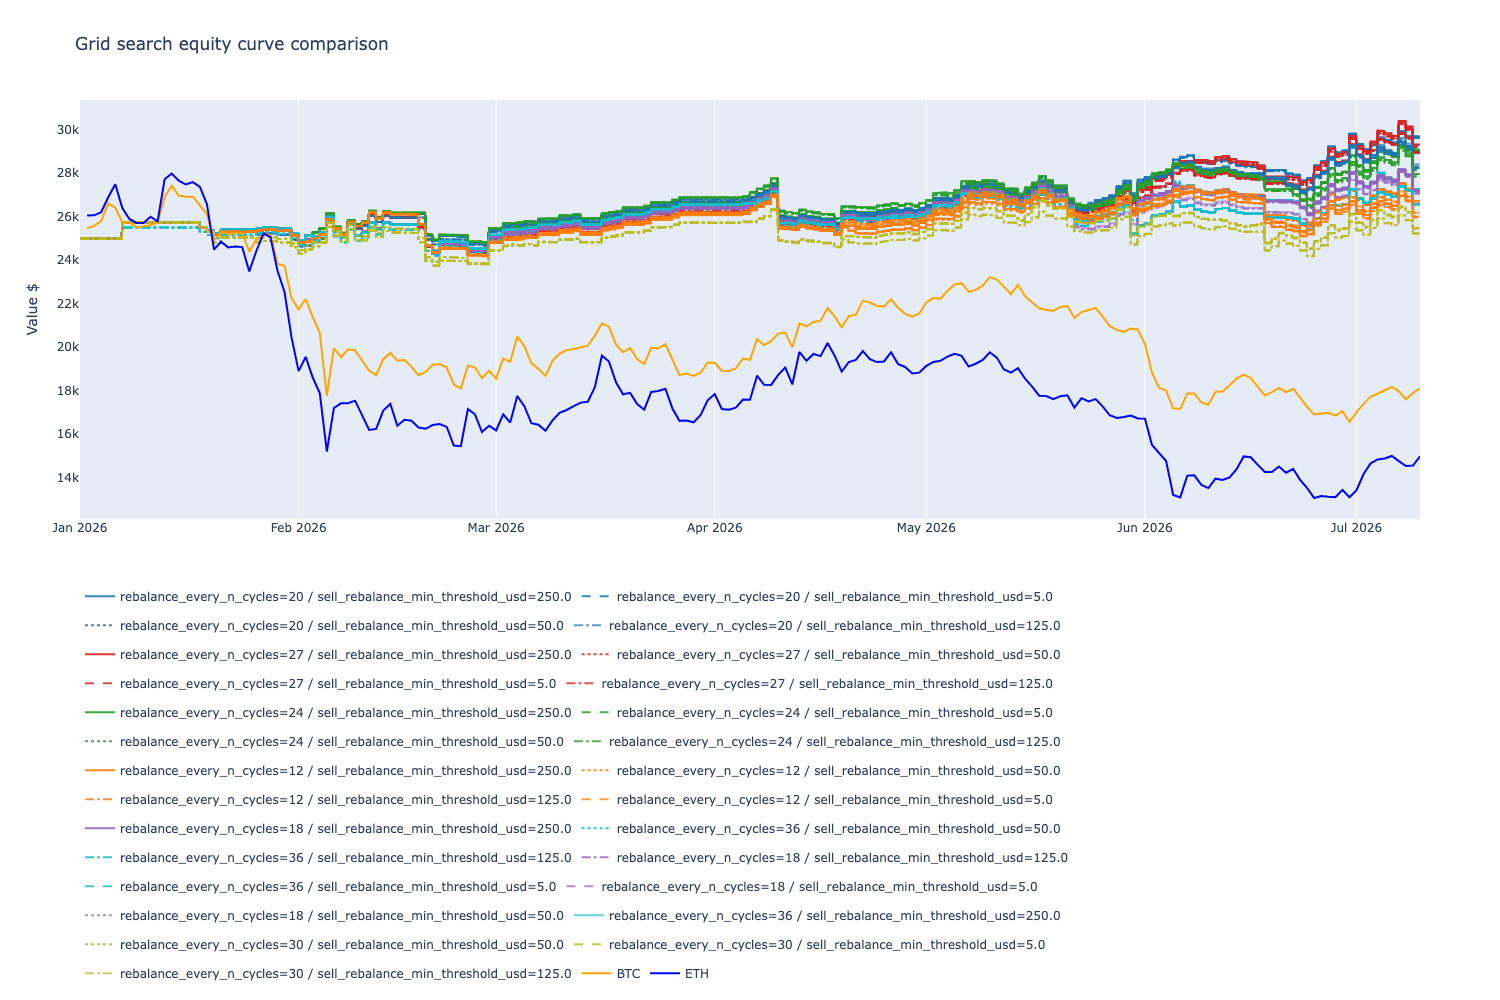

In [12]:
from tradeexecutor.visual.grid_search_basic import visualise_grid_search_equity_curves
from tradeexecutor.analysis.multi_asset_benchmark import get_benchmark_data

# Automatically create BTC and ETH buy and hold benchmark if present
# in the trading universe
benchmark_indexes = get_benchmark_data(
    strategy_universe,
    cumulative_with_initial_cash=Parameters.initial_cash,
    start_at=pd.Timestamp(Parameters.backtest_start),
)

# Extract GridSearchResult instances from optimiser results.
#
# `ignore_wallet_errors=True` turns a crashed backtest into a placeholder GridSearchResult whose
# equity curve is indexed at 1970-01-01/02 (see create_grid_search_failed_result). Those rows are
# not removed by `r.filtered`, which only reflects the MinTradeCountFilter, so leaving them in
# stretches the chart's x axis from 1970 to 2026 and flattens every real curve into a vertical line.
candidates = [r.result for r in optimiser_result.results if not r.filtered]
grid_search_results = [r for r in candidates if r.exception is None]
failed = len(candidates) - len(grid_search_results)
if failed:
    print(f"Excluding {failed} backtest(s) that failed with an exception from the equity curve chart")

fig = visualise_grid_search_equity_curves(
    grid_search_results,
    benchmark_indexes=benchmark_indexes,
    log_y=False,
    group_by="rebalance_every_n_cycles",
    group_by_secondary="sell_rebalance_min_threshold_usd",
)
fig.show()

# Parameter analysis

## Decision tree visualisation

Analysing Sharpe for parameters: ['minimum_hold_days', 'rebalance_every_n_cycles', 'sell_rebalance_min_threshold_usd']


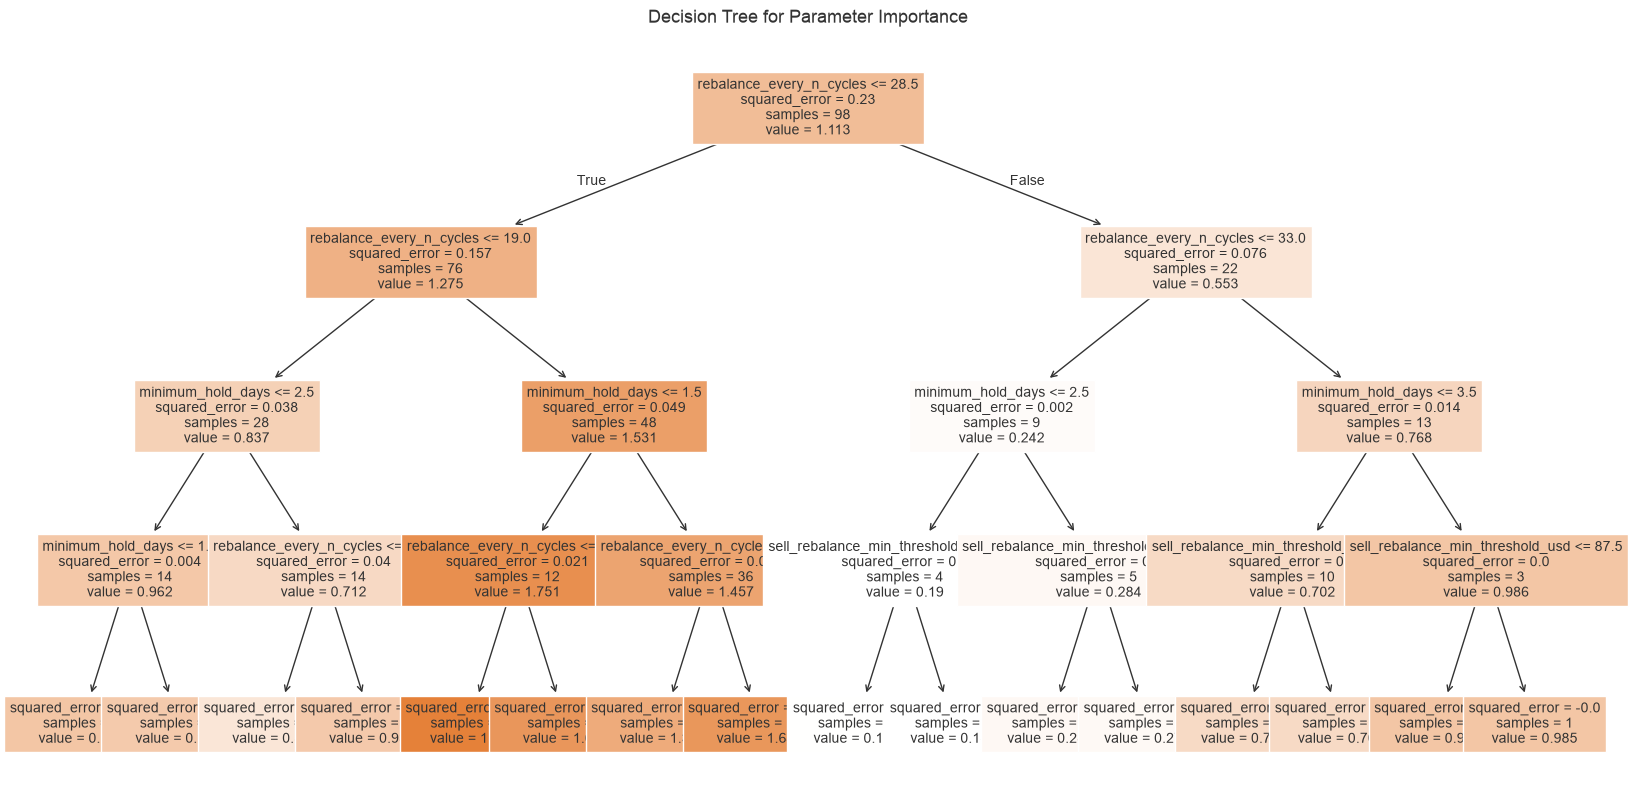

In [13]:
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor, plot_tree

parameter_names = list(df.index.names)
parameter_df = df
parameter_df = parameter_df.reset_index()

analysis_metric = "Sharpe"
print(f"Analysing {analysis_metric} for parameters: {parameter_names}")

# Prepare data
X = parameter_df[parameter_names]
y = parameter_df[analysis_metric]

# Convert categorical values if needed
for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])

# Train a simple decision tree
tree = DecisionTreeRegressor(max_depth=4)
tree.fit(X, y)

# Plot
plt.figure(figsize=(20, 10))
plot_tree(tree, feature_names=X.columns, filled=True, fontsize=10)
plt.title('Decision Tree for Parameter Importance')
plt.show()

## Feature importance analysis

Use a regression model to determine which parameters have the strongest influence.



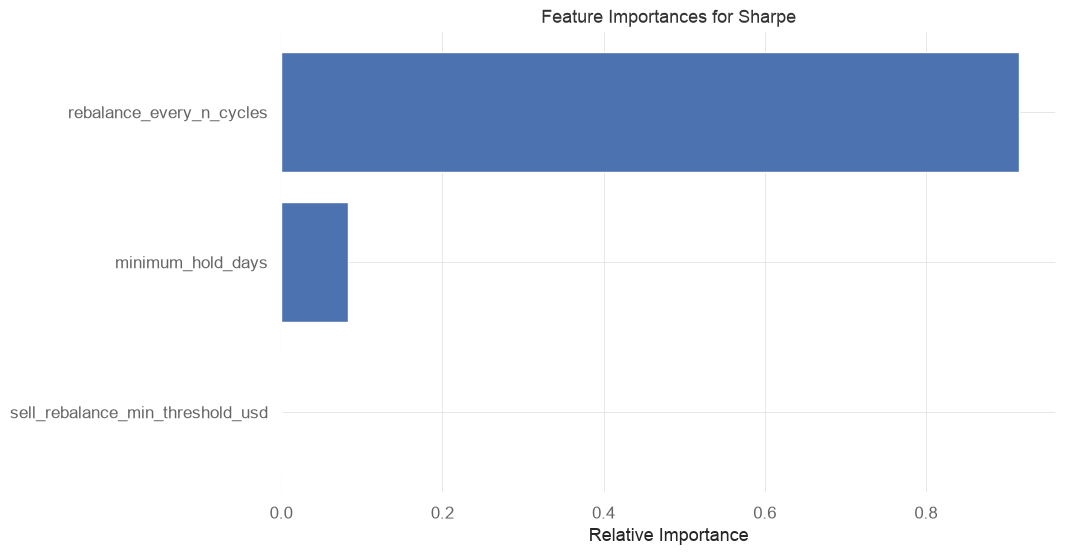

In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
X = parameter_df[parameter_names]
y = parameter_df[analysis_metric]

# Convert categorical values to numeric if needed
for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])

# Train a random forest model
model = RandomForestRegressor(n_estimators=100)
model.fit(X, y)

# Plot feature importances
importances = model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title(f'Feature Importances for {analysis_metric}')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

## Heatmaps for parameter pairs

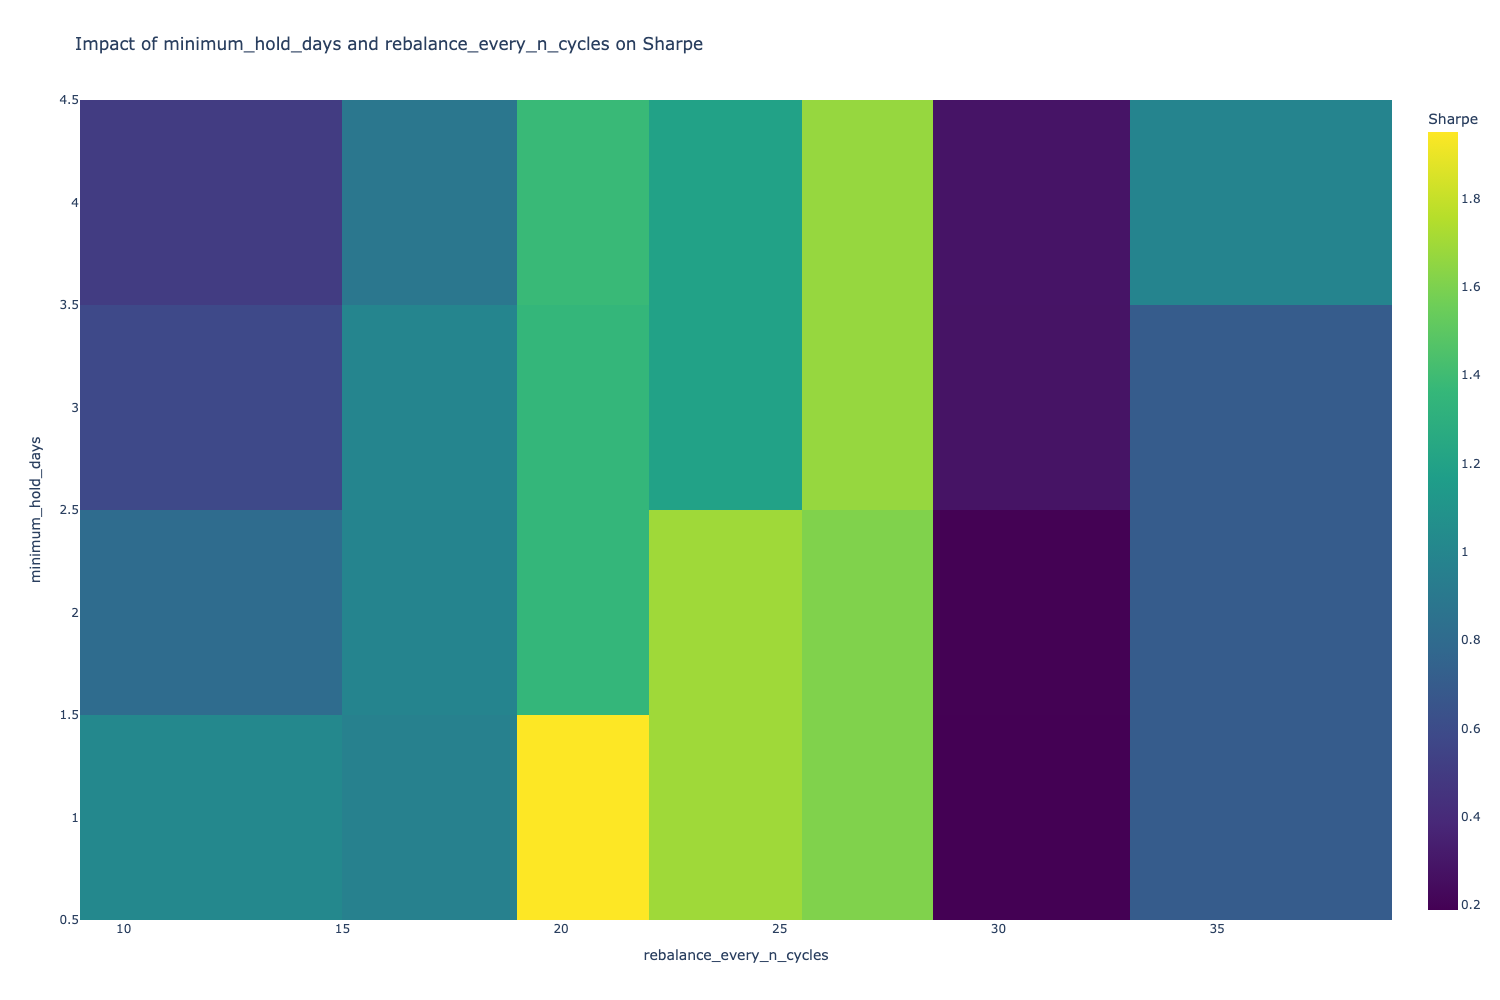

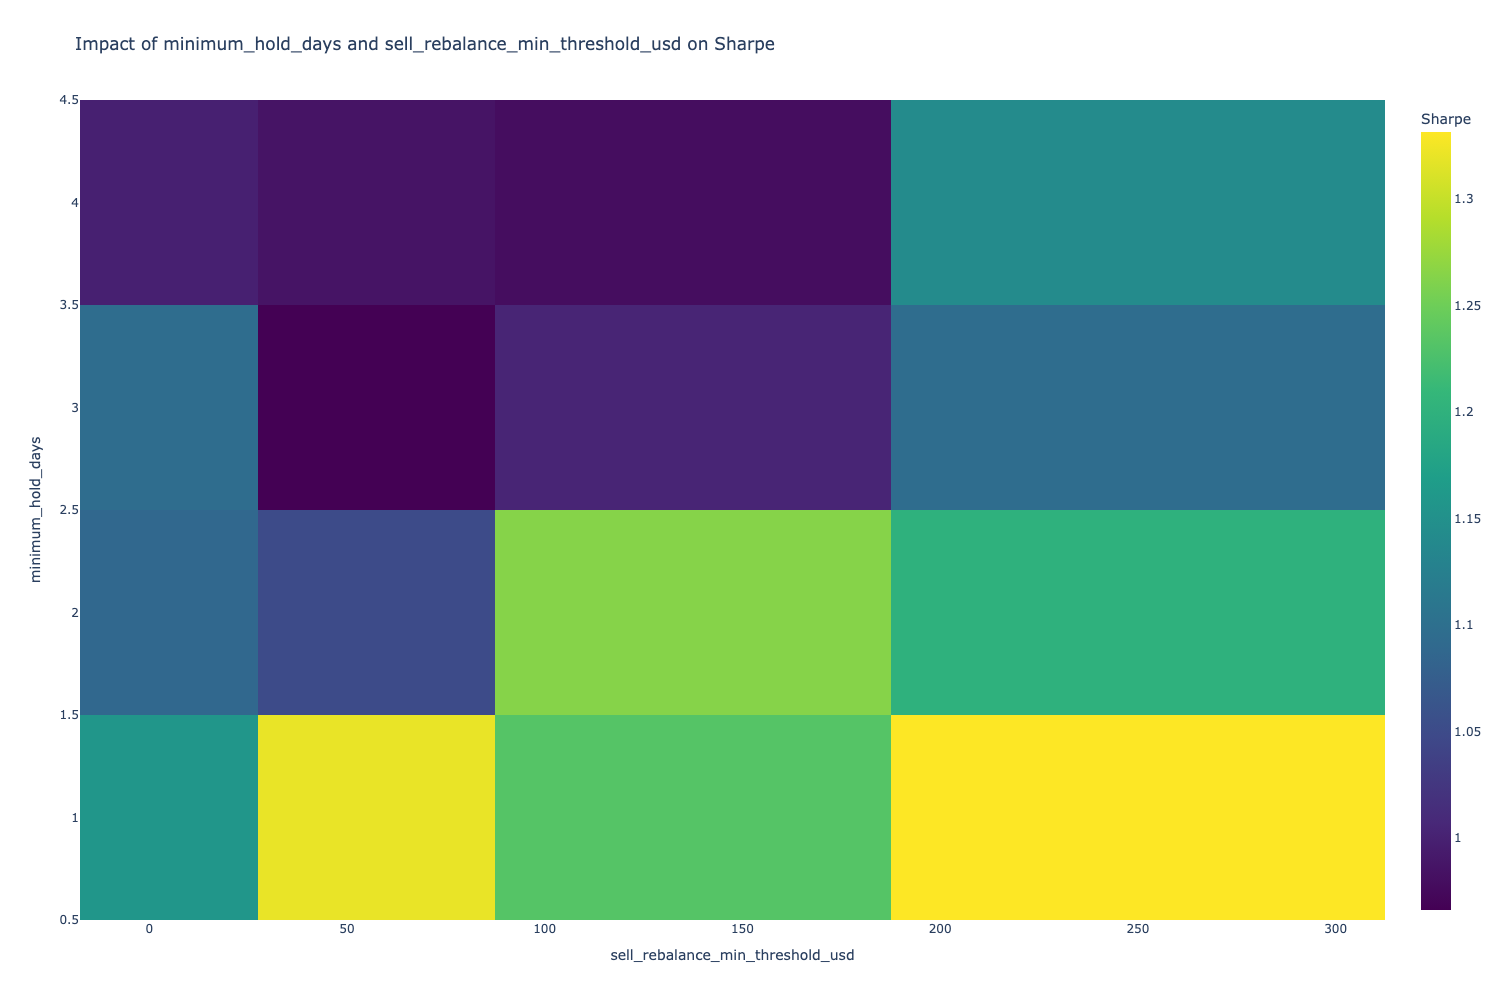

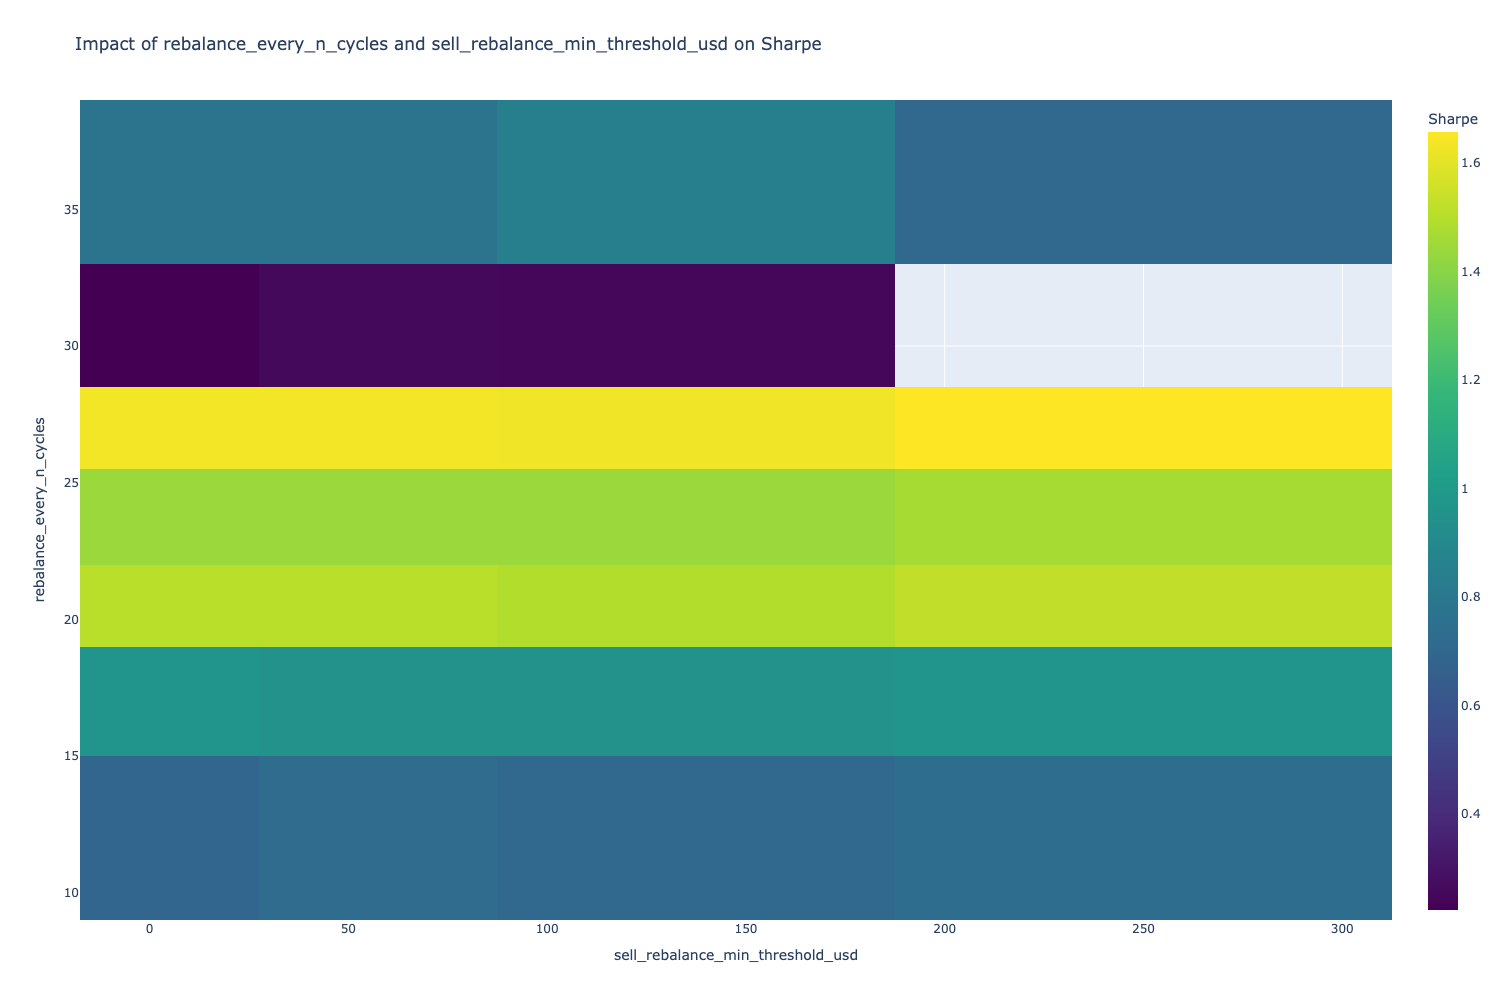

In [15]:
import plotly.graph_objects as go
import numpy as np

def create_heatmap(df, param1, param2, metric):
    # Create pivot table
    pivot = df.pivot_table(
        values=metric, 
        index=param1,
        columns=param2,
        aggfunc="mean"
    )
    
    fig = go.Figure(data=go.Heatmap(
        z=pivot.values,
        x=pivot.columns,
        y=pivot.index,
        colorscale='Viridis',
        colorbar=dict(title=metric)
    ))
    
    fig.update_layout(
        title=f'Impact of {param1} and {param2} on {metric}',
        xaxis_title=param2,
        yaxis_title=param1
    )
    
    return fig

# All parameter pairs, not just consecutive ones - the consecutive-only loop skipped
# hold x softband entirely.
from itertools import combinations

param_pairs = list(combinations(parameter_names, 2))

for param1, param2 in param_pairs:
    fig = create_heatmap(parameter_df, param1, param2, metric=analysis_metric)
    fig.show()

## Cluster analysis

cluster      CAGR                              Sharpe                      \
               mean       min       max count      mean       min       max   
0       0  0.226537  0.077167  0.391907    25  1.198687  0.495726  1.954453   
1       1  0.208400  0.036229  0.352027    25  1.059955  0.276854  1.662198   
2       2  0.252164  0.125631  0.394809    14  1.285944  0.701001  1.956178   
3       3  0.184006  0.078868  0.361300    16  0.976495  0.504120  1.697201   
4       4  0.204018  0.017507  0.336822    18  1.054773  0.186552  1.694004   

     Max DD                      
       mean       min       max  
0 -0.068159 -0.076156 -0.063784  
1 -0.070703 -0.082021 -0.063331  
2 -0.069081 -0.076541 -0.064571  
3 -0.070862 -0.077980 -0.063784  
4 -0.072497 -0.081854 -0.066105

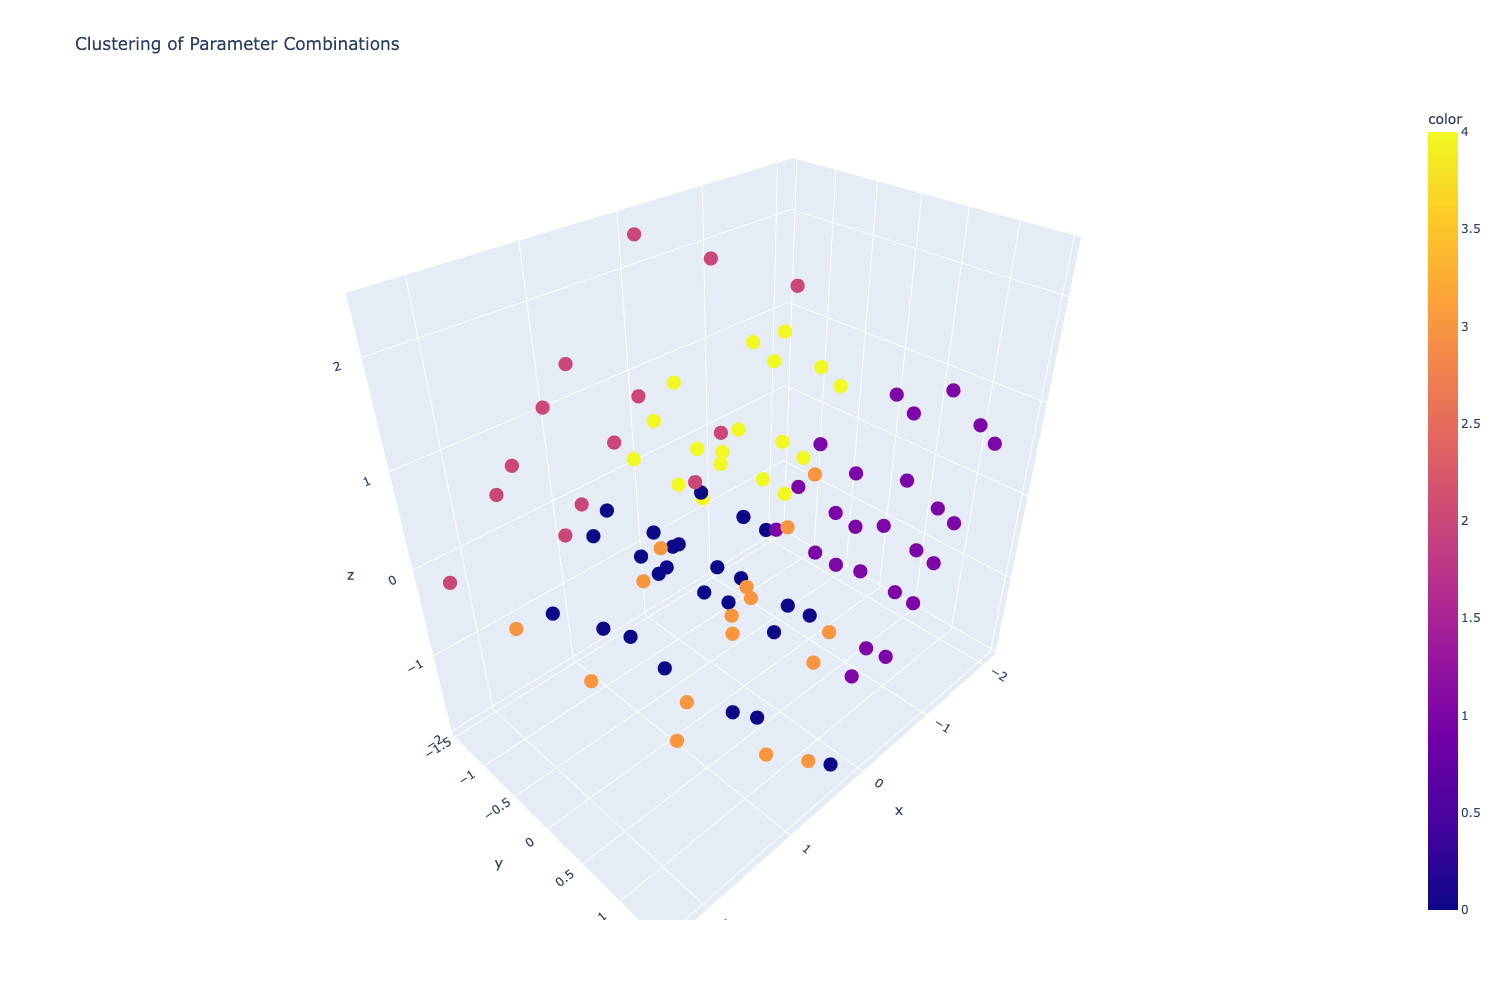

In [16]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import plotly.express as px

# Select features for clustering
features = parameter_names
X = parameter_df[features]

# Convert categorical values to numeric
for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-means clustering (determine optimal k separately)
kmeans = KMeans(n_clusters=5, random_state=42)
parameter_df['cluster'] = kmeans.fit_predict(X_scaled)

# Analyze performance by cluster
cluster_perf = parameter_df.groupby('cluster').agg({
    'CAGR': ['mean', 'min', 'max', 'count'],
    'Sharpe': ['mean', 'min', 'max'],
    'Max DD': ['mean', 'min', 'max']
}).reset_index()

display(cluster_perf)

# Visualize clusters in 3D space (using first 3 PCA components)
from sklearn.decomposition import PCA

try:
    pca = PCA(n_components=3)
    components = pca.fit_transform(X_scaled)

    fig = px.scatter_3d(
        x=components[:, 0],
        y=components[:, 1],
        z=components[:, 2],
        color=parameter_df['cluster'],
        hover_data={'Sharpe': parameter_df['Sharpe'], 'CAGR': parameter_df['CAGR']},
        title='Clustering of Parameter Combinations'
    )
    fig.show()
except ValueError as e:
    print(f"Error in PCA: {e}")
    print("PCA failed, possibly due to too few features or singular matrix.")
    # Handle the error as needed

## Parallel coordinates plot

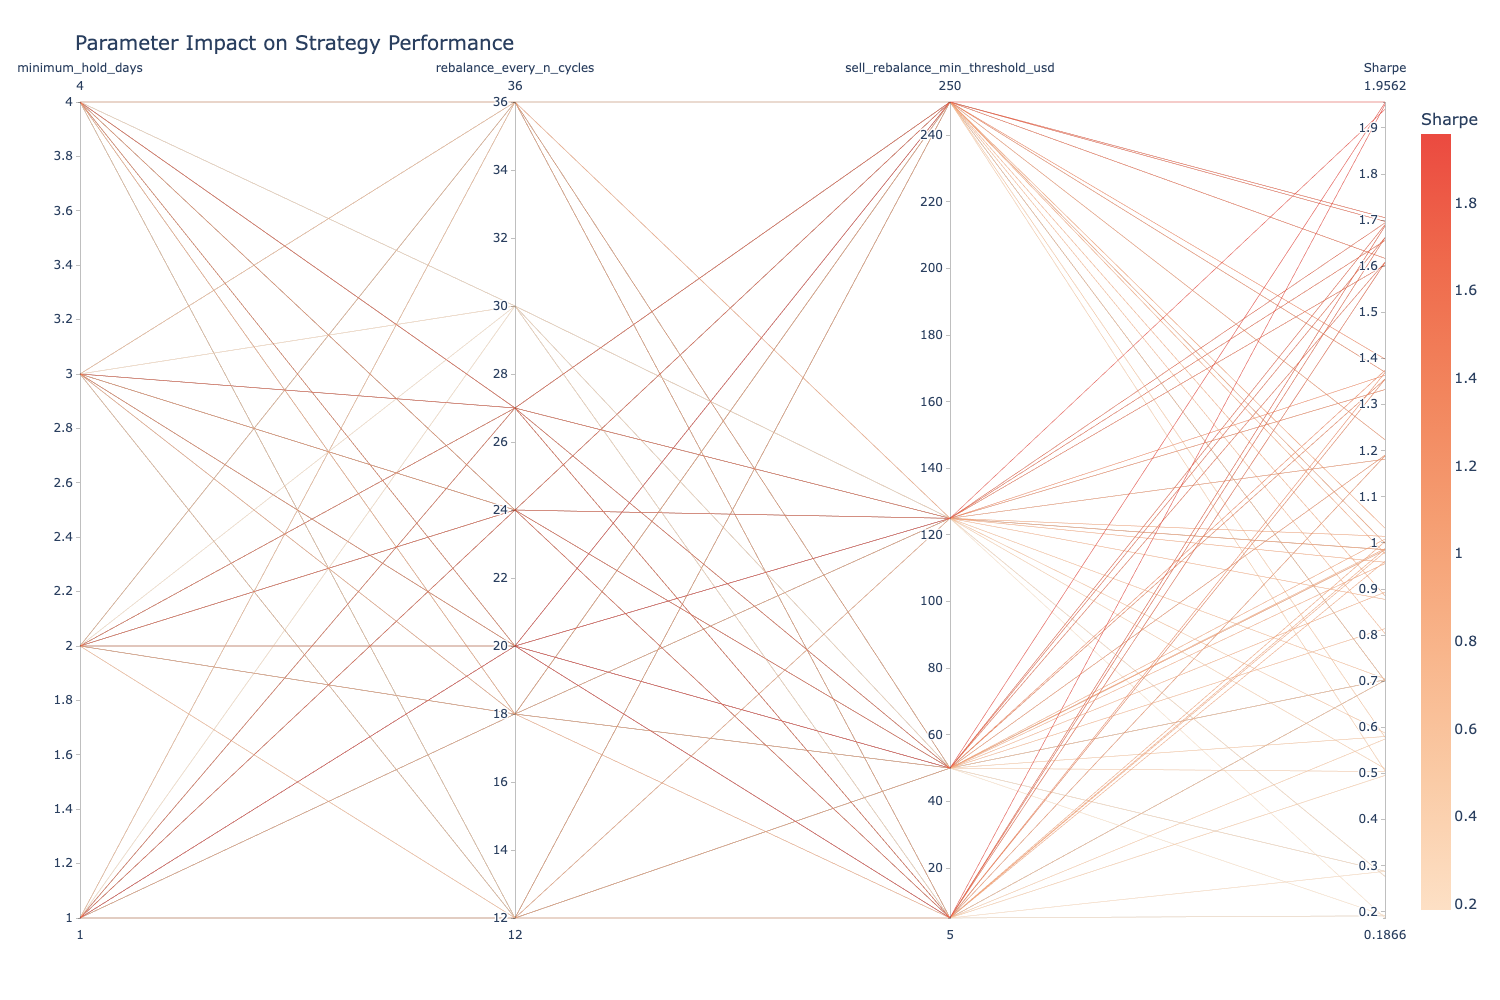

In [17]:
import plotly.express as px

# Extract top results (e.g., top 50)
top_results = parameter_df.head(50)

dimensions = parameter_names + [analysis_metric]

# Create parallel coordinates plot
fig = px.parallel_coordinates(
    parameter_df,
    dimensions=dimensions,
    color=analysis_metric,
    color_continuous_scale=px.colors.sequential.Peach,
    title='Parameter Impact on Strategy Performance'
)


# Increase font size for axis titles, tick labels, and title
fig.update_layout(
    font=dict(size=14),  # Base font size for the whole figure
    title=dict(
        text='Parameter Impact on Strategy Performance',
        font=dict(size=20)  # Title font size
    ),
    coloraxis_colorbar=dict(
        title=dict(
            text=analysis_metric,
            font=dict(size=16)
        ),
        tickfont=dict(size=14)
    )
)

# Parallel coordinates chart: Line width not supported
# https://github.com/plotly/plotly.js/issues/2573

fig.show()

# The best candidate equity curve

The best result found for <function optimise_sharpe at 0x12dba7060> was <GridSearchResult
  #9, minimum_hold_days=1, rebalance_every_n_cycles=20, sell_rebalance_min_threshold_usd=250.0
  CAGR: 39.00%, Sharpe: 1.96, Sortino: 2.89, Max drawdown:-7.00%
>


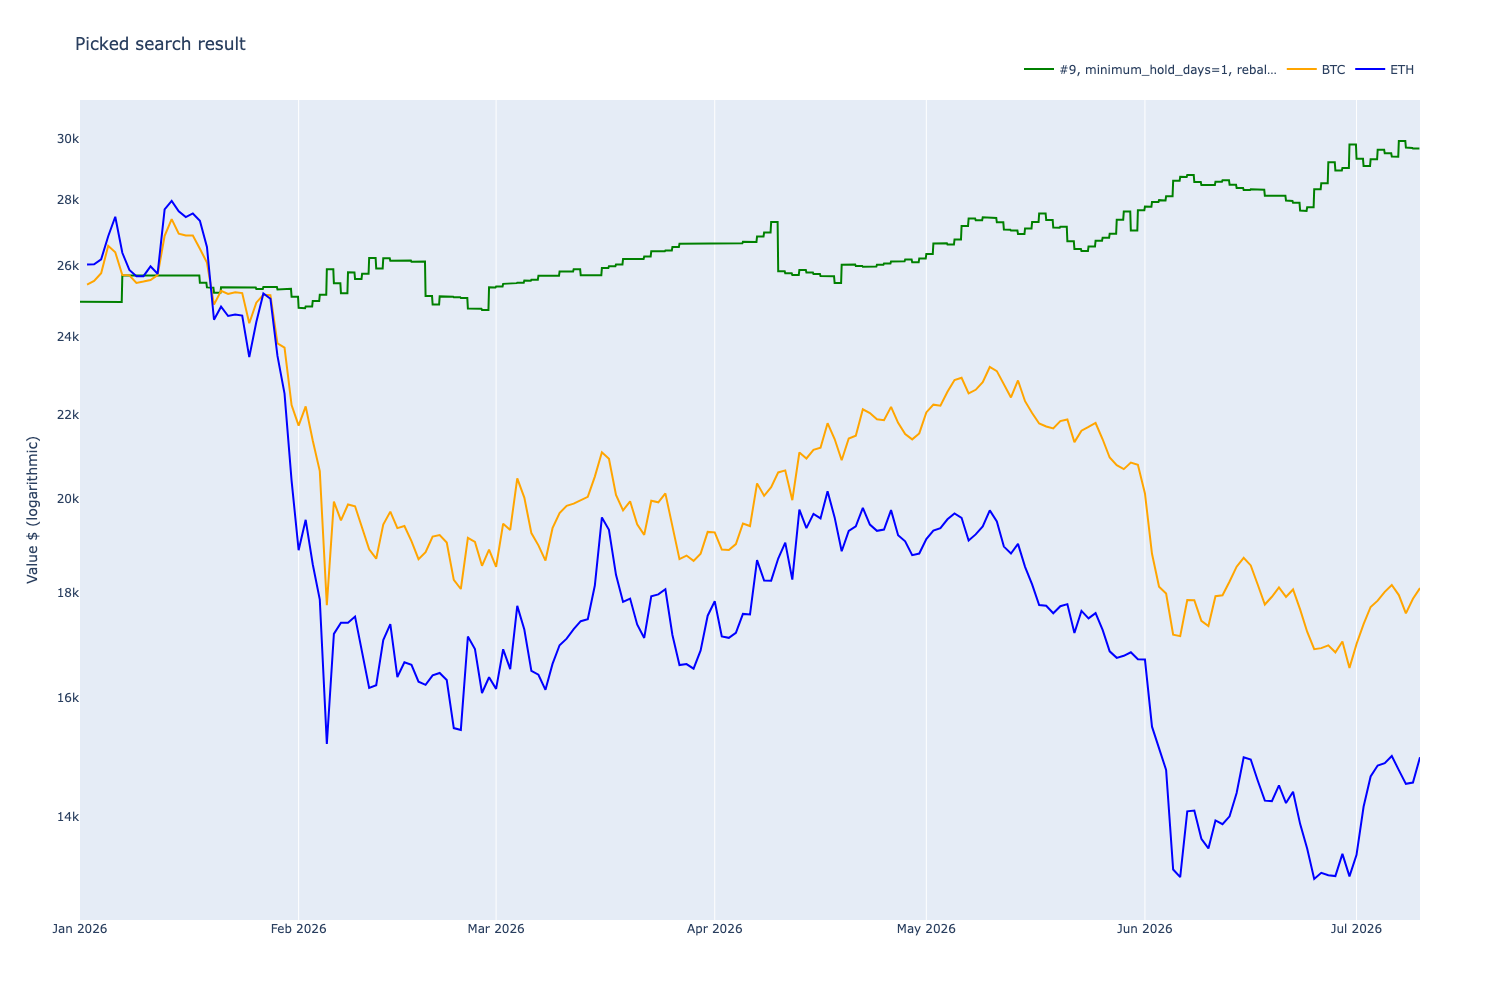

In [18]:
from tradeexecutor.visual.grid_search import visualise_single_grid_search_result_benchmark

# GridSearchResult instance that gave the best performance
best_pick = next(result.result for result in optimiser_result.results if not result.filtered)
state = best_pick.hydrate_state()

print(f"The best result found for {search_func} was {best_pick}")

fig = visualise_single_grid_search_result_benchmark(
    best_pick, 
    strategy_universe, 
    initial_cash=Parameters.initial_cash,
    log_y=True,
)
fig.show()

# Portfolio performance (best pick)

- Compare buy and hold against our best performance

In [19]:
from tradeexecutor.analysis.multi_asset_benchmark import compare_strategy_backtest_to_multiple_assets

returns = best_pick.returns

df = compare_strategy_backtest_to_multiple_assets(
    state=state,
    strategy_universe=strategy_universe,
    returns=returns,
    display=True,
    asset_count=3,
)
display(df)

,Strategy,BTC,ETH
Start Period,2026-01-01,2026-01-01,2026-01-01
End Period,2026-07-09,2026-07-09,2026-07-09
Risk-Free Rate,0.0%,0.0%,0.0%
Time in Market,94.0%,99.0%,98.0%
Cumulative Return,18.8%,-30.05%,-44.17%
CAGR﹪,39.48%,-49.85%,-67.55%
Sharpe,1.96,-1.17,-1.4
Prob. Sharpe Ratio,91.05%,19.95%,15.7%
Smart Sharpe,1.85,-1.1,-1.33
Sortino,2.89,-1.58,-1.89


# Trade summary (best pick)

- Show statistics about the made trades

In [20]:
summary = best_pick.summary
display(summary.to_dataframe())

,0
Trading period length,188 days 8 hours
Trading start,None
Trading end,None
Return %,18.69%
Annualised return %,36.22%
Cash at start,"$25,000.00"
Value at end,"$29,671.88"
Time in market,0.00%
Time in market volatile,0.00%
Trade volume,"$678,071.79"


# Trading pair performance breakdown

- Show breakdown of different pairs on the best result

In [21]:
from tradeexecutor.analysis.multipair import analyse_multipair
from tradeexecutor.analysis.multipair import format_multipair_summary

multipair_summary = analyse_multipair(state)
display(format_multipair_summary(multipair_summary))

,Trading pair,Positions,Trades,Total return %,Total PnL USD,Best,Worst,Avg,Median,Volume,Wins,Losses,Take profits,Stop losses,Trailing stop losses,Volatility
2,Realist Capital,4,55,74.72%,"3,463.92",53.71%,0.28%,18.68%,10.37%,"49,713.90",4,0,0,0,0,20.76%
24,HyperProfit {PRO},2,5,25.82%,355.30,23.73%,2.10%,12.91%,12.91%,"6,473.87",2,0,0,0,0,10.81%
3,Scared Money,7,31,22.08%,294.60,30.30%,-17.06%,3.15%,-0.10%,"22,902.72",3,4,0,0,0,15.34%
0,Goon Edging,4,30,18.22%,"1,673.25",19.29%,-10.93%,4.55%,4.93%,"50,143.36",3,1,0,0,0,10.76%
7,Growi HF,1,3,6.11%,223.06,6.11%,6.11%,6.11%,6.11%,"7,520.27",1,0,0,0,0,0.00%
5,pmalt,3,57,3.62%,961.85,5.08%,-2.19%,1.21%,0.72%,"52,209.42",2,1,0,0,0,2.99%
1,Mad Scientists,1,9,2.26%,140.69,2.26%,2.26%,2.26%,2.26%,"7,627.72",1,0,0,0,0,0.00%
9,Mahamor,2,8,1.86%,69.88,1.96%,-0.10%,0.93%,0.93%,"14,508.30",1,1,0,0,0,1.03%
25,OIB,1,7,1.68%,128.79,1.68%,1.68%,1.68%,1.68%,"15,432.55",1,0,0,0,0,0.00%
4,69 Jump Street,4,14,0.98%,105.34,0.96%,-0.51%,0.25%,0.27%,"59,698.74",2,2,0,0,0,0.66%


# Best positions

- Find positions that made most profit for the leading backtest

In [22]:
profit_by_position = [(p.get_realised_profit_usd(), p) for p in state.portfolio.get_all_positions()]
profit_by_position.sort(key=lambda t: t[0] or -999_999_999, reverse=True)

data = []

for profit, p in profit_by_position[0:5]:
    data.append({
        "Profit USD": profit,
        "Pair": p.pair.get_ticker(),
        "Position id": p.position_id,
        "Opened": p.opened_at,
        "Closed": p.closed_at,
        "Duration": p.closed_at - p.opened_at if p.closed_at else "(still open)",
        "Open price": p.get_opening_price(),
        "Close price": p.get_closing_price(),
        "Trades": p.get_trade_count(),
        "Price gain %": (p.get_closing_price() - p.get_opening_price()) / p.get_opening_price() * 100,
        "Weight at open %": p.get_capital_tied_at_open_pct() * 100,
    })

df = pd.DataFrame(data)
display(df)

,Profit USD,Pair,Position id,Opened,Closed,Duration,Open price,Close price,Trades,Price gain %,Weight at open %
0,1017.866444,pmalt-USDC,7,2026-01-04 08:00:00,2026-05-21 00:00:00,136 days 16:00:00,10.323048,11.255627,48,9.033952,5.267307
1,981.921307,Goon Edgin-USDC,45,2026-05-24 08:00:00,2026-06-15 00:00:00,21 days 16:00:00,1.337932,1.522723,10,13.811733,11.607701
2,975.207548,Realist Ca-USDC,28,2026-03-08 16:00:00,2026-05-31 00:00:00,83 days 08:00:00,3.718453,4.395405,38,18.205207,12.516800
3,860.759637,Realist Ca-USDC,49,2026-06-03 08:00:00,2026-06-18 08:00:00,15 days 00:00:00,4.262141,3.327404,8,-21.931156,16.587930
4,634.470615,Goon Edgin-USDC,16,2026-02-01 16:00:00,2026-02-20 00:00:00,18 days 08:00:00,1.524321,1.746880,7,14.600518,11.342881


# Rolling sharpe

- The rolling sharpe ratio of the best pick

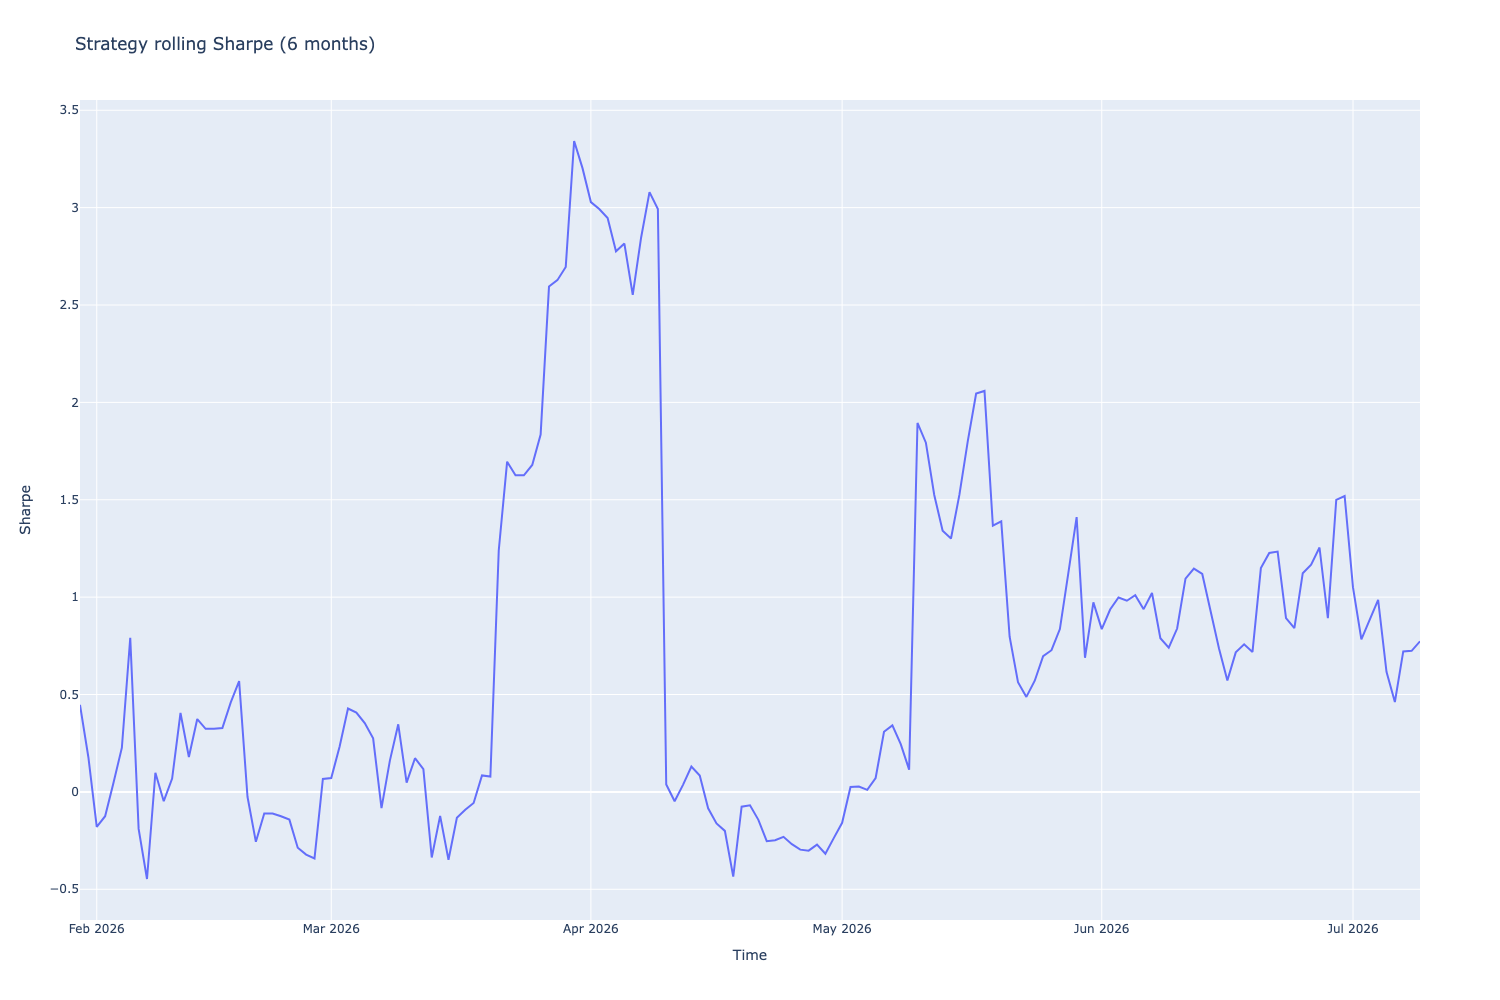

In [23]:
import plotly.express as px

from tradeexecutor.visual.equity_curve import calculate_equity_curve, calculate_returns
from tradeexecutor.visual.equity_curve import calculate_rolling_sharpe

# A 180-day window over a ~190-day backtest leaves ~10 points; 30 days is readable.
rolling_sharpe = calculate_rolling_sharpe(
    returns,
    freq="D",
    periods=30,
)

fig = px.line(rolling_sharpe, title='Strategy rolling Sharpe (6 months)')
fig.update_layout(showlegend=False)
fig.update_yaxes(title="Sharpe")
fig.update_xaxes(title="Time")
fig.show()

# Data diagnosics

- Some example code to track down issues with data


In [24]:
# data = [{"Timestamp": s.calculated_at, "Equity": s.net_asset_value} for s in state.stats.portfolio]
# df = pd.DataFrame(data)
# df = df.set_index("Timestamp")

# with pd.option_context('display.min_rows', 50, "display.max_rows", 50):
#     display(df)

In [25]:
# for t in state.portfolio.get_all_trades():
#     if t.executed_at.date() == datetime.date(2023, 12, 29):
#         print(t, t.pair, t.get_value())

In [26]:
# import plotly.graph_objects as go

# pair_desc = (ChainId.ethereum, "uniswap-v3", "WBTC", "USDC", 0.0005)
# pair = strategy_universe.get_pair_by_human_description(pair_desc)
# df = strategy_universe.data_universe.candles.get_candles_by_pair(pair.internal_id)


# fig = go.Figure(data=go.Ohlc(x=df.timestamp,
#                     open=df.open,
#                     high=df.high,
#                     low=df.low,
#                     close=df.close))
# fig.show()

# with pd.option_context('display.min_rows', 5000, "display.max_rows", 5000, 'display.float_format', lambda x: f'{x:.6f}'):
#     display(df)